# Understat data explanation and cleaning

---

## Introduction:
### The first thing that I am planning to do, is to gather a better look at what we have as a data!

I am going to follow a process of obtaining each of the datasets one by one, understand their structure, features, details and try to figure out some important insights!

After understanding the data, its structure, what it contains, are there any inconsistencies in it, some missing values etc, I will have a better look at what am I going to work with and more importanly here could be formed some major and useful assumptions, which by being documentated clearly and defined properly, later will be much easier for me, because I will already know to what I should be looking at and also how to deal with it!

This article will be about exploring the Understat datasets, understand their structures, what they contain and for what the data will be used?Each of the Understats datasets will be cleaned and prepared for analyses and modeling!

So I think we are ready to start exploring the data! \
First thing I will do, is to load the necessary libraries which will be used in this notebook!

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

from football_betting_analysis.config import UNDERSTAT_INTERIM_PATH, START_SEASON, END_SEASON

from football_betting_analysis.data.text_cleaning import clean_text_values
from football_betting_analysis.data.save_data_into_file import save_data
from football_betting_analysis.data.data_cleaning import convert_string_to_datetime, optimize_dataframe_memory

After that we have installed the necessary libraries, it's time to load the datasets!

As the `README` should have specified, the datasets should be loaded and stored in the appropriate folders at the start of the project, after the installation of the required libraries!This should happen after running the specified command `python -m football_betting_analysis.data.load_datasets` for the execution of the script which is in the following location `src\football_betting_analysis\data\load_datasets.py` which fetches the data and stores it into the appropriate folders!

Ok, I suppose that the data is already fetched and stored into folders and we can begin the exploration! \
As I have already mentioned, I will be exploring the datasets one by one!

<a class='anchor' id='understat_section'></a>

## Understat

The understat dataset is not one dataset, but four separate ones including: **matches**, **mathces_shots**, **players** and **teams_context**.

Actually, the reason that I have choosed to work with this data source is that **Understat** gives one very essential and important metric in football, which **plays a big role in the statistcial models and highly influence their results**.This metric is called: **expected goals** or abbreviated as **xG**(That's how it will be mostly seen among the the datasets).The metric does not only reffer to goals, but also could be for assists, shots and actually at any kind of event in a football match!

The official description of the expected goal metric is:
> Expected Goals (xG) in football is a statistical metric measuring the probability that a specific shot will result in a goal, ranging from 0.00 to 1.00. It calculates chance quality rather than just quantity, with 0.10 xG representing a 10% chance to score, and 0.90 xG representing a 90% chance.

One thing I want to clarify is that the provided expected goals in this specific dataset are not expected goals for a shot, but they are the **cumulative (total) xG** for a match or a season, not just the probability of a single shot.While it is true that an individual shot is modeled with a probability between 0 and 1 (where 1 is a 100% chance of scoring, such as a penalty's $(\approx 0.76)$ xG), the total xG is calculated by summing the probabilities of all shots taken by a player or team!

How it is calculated:
xG models use historical data from thousands of similar shots, situations, events and analyze several variables to assign a probability value to a shot.Here are some of the factors which are taken into account for the calculation:

* Distance and Angle:  \
    Closer, central shots have higher xG; farther, angled shots have lower xG.

* Body Part: \
    Shots taken with the foot generally have a higher xG than headers.

* Pattern of Play: \
    Whether the shot followed a through ball, cross, dribble, or was a set-piece.

* Defensive Pressure: \
    The number of defenders and goalkeeper positioning, which affects the clarity of the path to the goal.

**Cumulative Summation**: If a team takes 10 shots in a game, each with an average of 0.20 xG (a 20% chance), the total xG for that team is $(10 \times 0.20 = 2.0)$. This means that based on the quality of chances, they were expected to score 2 goals, even though no single shot was worth more than 1.

We can see that this is a very big process, which either very complicated and it requires many different techniques and components!

With **Understat** we get all of this **expected metrics** already calculated and ready to use.
Anyway, aside from this digression, I just wanted to explain the metric right now because it is very important for the future analyses and especially for the models predictions!

So, lets load each of the components:

In [2]:
us_matches = pd.read_csv('../data/raw/understat_data/matches.csv')

Ok, we have loaded all of the understat data, now lets expect each of its components one by one:

<a id='understat_section_matches'></a>
#### Mathces:

In [3]:
us_matches

,id,isResult,datetime,season,h_id,h_title,h_short_title,a_id,a_title,a_short_title,goals_h,goals_a,xG_h,xG_a,forecast_w,forecast_d,forecast_l
0,5826,True,2014-08-23 18:00:00,2014/2015,137,Malaga,MAL,147,Athletic Club,ATH,1,0,1.321070,1.141510,0.3996,0.3315,0.2689
1,5827,True,2014-08-23 20:00:00,2014/2015,138,Sevilla,SEV,146,Valencia,VAL,1,1,1.171970,1.749030,0.1984,0.2906,0.5110
2,5828,True,2014-08-23 20:00:00,2014/2015,155,Granada,GRA,139,Deportivo La Coruna,DEP,2,1,0.548351,0.379371,0.3244,0.4747,0.2009
3,5829,True,2014-08-23 22:00:00,2014/2015,208,Almeria,ALM,141,Espanyol,ESP,1,1,0.978788,0.399306,0.5100,0.3494,0.1406
4,5830,True,2014-08-24 18:00:00,2014/2015,156,Eibar,EIB,140,Real Sociedad,SOC,1,0,0.465398,0.975523,0.1580,0.3601,0.4819
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4175,27359,True,2025-05-24 19:00:00,2024/2025,142,Getafe,GET,152,Celta Vigo,CEL,1,2,0.358970,1.308180,0.0855,0.2655,0.6490
4176,27360,True,2025-05-24 19:00:00,2024/2025,145,Rayo Vallecano,RVL,239,Mallorca,MAL,0,0,2.119820,0.747939,0.7212,0.1840,0.0948
4177,27358,True,2025-05-25 12:00:00,2024/2025,223,Girona,GIR,143,Atletico Madrid,ATL,0,4,0.050337,3.106370,0.0000,0.0025,0.9975
4178,27361,True,2025-05-25 14:15:00,2024/2025,154,Villarreal,VIL,138,Sevilla,SEV,4,2,1.288050,1.648290,0.2678,0.2780,0.4542


Lets see if the length of the columns and rows corresponds to the shape of the Data Frame:

In [4]:
us_matches.shape

(4180, 17)

We can see that the columns are more or less self explaining.One thing which us very important is that for each match we have a date and a match_id which will be used later when we merge the tables and combine the data!!!

As I have said, there are the expected goals merics, which are the: `xG_h, xG_a` which refers to expected goals home and expected goals away!The suffix H/h and A/a in almost all of the tables is refering to Home team and Away team(Just to be known)

One thing which is very interesting are these features: `forecast_w, forecast_d, forecast_l`.To what I know from the data source these columns refer to **model-estimated probabilities for home win, draw, and away win, generated by Understat based on xG and team strength models**.

- forecast_w -> Probability that the home team wins -> 39.96% of home winning
- forecast_d -> Probability of a draw -> 33.15% of draw
- forecast_l -> Probability that the away team wins -> 26.89% of away winning

These could be very useful for future model calibration analysis!

Ok now lets see memory usage info of the dataset:

In [5]:
us_matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 4180 entries, 0 to 4179
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             4180 non-null   int64  
 1   isResult       4180 non-null   bool   
 2   datetime       4180 non-null   str    
 3   season         4180 non-null   str    
 4   h_id           4180 non-null   int64  
 5   h_title        4180 non-null   str    
 6   h_short_title  4180 non-null   str    
 7   a_id           4180 non-null   int64  
 8   a_title        4180 non-null   str    
 9   a_short_title  4180 non-null   str    
 10  goals_h        4180 non-null   int64  
 11  goals_a        4180 non-null   int64  
 12  xG_h           4180 non-null   float64
 13  xG_a           4180 non-null   float64
 14  forecast_w     4180 non-null   float64
 15  forecast_d     4180 non-null   float64
 16  forecast_l     4180 non-null   float64
dtypes: bool(1), float64(5), int64(5), str(6)
memory usage: 741.9 KB

We can see that there are no missing or null values.This is important!But lets check it to ensure everything is ok:

In [6]:
us_matches.count()

id               4180
isResult         4180
datetime         4180
season           4180
h_id             4180
h_title          4180
h_short_title    4180
a_id             4180
a_title          4180
a_short_title    4180
goals_h          4180
goals_a          4180
xG_h             4180
xG_a             4180
forecast_w       4180
forecast_d       4180
forecast_l       4180
dtype: int64

In [7]:
us_matches.notna().all()

id               True
isResult         True
datetime         True
season           True
h_id             True
h_title          True
h_short_title    True
a_id             True
a_title          True
a_short_title    True
goals_h          True
goals_a          True
xG_h             True
xG_a             True
forecast_w       True
forecast_d       True
forecast_l       True
dtype: bool

About the columns, most of them seem to be with the right data types, except the datetime column which is string!

Lets see the data types:

In [8]:
us_matches.dtypes

id                 int64
isResult            bool
datetime             str
season               str
h_id               int64
h_title              str
h_short_title        str
a_id               int64
a_title              str
a_short_title        str
goals_h            int64
goals_a            int64
xG_h             float64
xG_a             float64
forecast_w       float64
forecast_d       float64
forecast_l       float64
dtype: object

Well, everything seems to be fine, and the only thing that should be fixed is the type of the datetime column!We should parse this type to a datetime!

As we are going to modify the datasets, it is absolutely mandatory to do this into a new dataset, not over the raw ones.The data which will be processed into this notebook and in the others, will be stored into the `\data\interim` folder.The purpose of this folder is to keep intermediate datasets that have been transformed or cleaned but are not yet in their final form!

So for each of the datasets that will be observed and cleaned into these notebooks, there should be created the corresponding foder which will store the interim version of their dataset!

So lets create afolder for the Understat dataset:

In [9]:
# The UNDERSTAT_INTERIM_PATH is a constant defined in the scr/config.py script which is used to store global variables and important constants among the project!
# force working directory to project root
PROJECT_ROOT = Path().resolve().parent

file_path = PROJECT_ROOT / UNDERSTAT_INTERIM_PATH
file_path.mkdir(parents=True, exist_ok=True)

Ok, now as we have created the folder where the **interim understat dataset** will be stored, we should make a **copy** of the original raw dataset so that we can ensure that there is no chance the raw dataset to be modifed!

In [10]:
us_matches_interim = us_matches.copy()

In [11]:
us_matches_interim

,id,isResult,datetime,season,h_id,h_title,h_short_title,a_id,a_title,a_short_title,goals_h,goals_a,xG_h,xG_a,forecast_w,forecast_d,forecast_l
0,5826,True,2014-08-23 18:00:00,2014/2015,137,Malaga,MAL,147,Athletic Club,ATH,1,0,1.321070,1.141510,0.3996,0.3315,0.2689
1,5827,True,2014-08-23 20:00:00,2014/2015,138,Sevilla,SEV,146,Valencia,VAL,1,1,1.171970,1.749030,0.1984,0.2906,0.5110
2,5828,True,2014-08-23 20:00:00,2014/2015,155,Granada,GRA,139,Deportivo La Coruna,DEP,2,1,0.548351,0.379371,0.3244,0.4747,0.2009
3,5829,True,2014-08-23 22:00:00,2014/2015,208,Almeria,ALM,141,Espanyol,ESP,1,1,0.978788,0.399306,0.5100,0.3494,0.1406
4,5830,True,2014-08-24 18:00:00,2014/2015,156,Eibar,EIB,140,Real Sociedad,SOC,1,0,0.465398,0.975523,0.1580,0.3601,0.4819
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4175,27359,True,2025-05-24 19:00:00,2024/2025,142,Getafe,GET,152,Celta Vigo,CEL,1,2,0.358970,1.308180,0.0855,0.2655,0.6490
4176,27360,True,2025-05-24 19:00:00,2024/2025,145,Rayo Vallecano,RVL,239,Mallorca,MAL,0,0,2.119820,0.747939,0.7212,0.1840,0.0948
4177,27358,True,2025-05-25 12:00:00,2024/2025,223,Girona,GIR,143,Atletico Madrid,ATL,0,4,0.050337,3.106370,0.0000,0.0025,0.9975
4178,27361,True,2025-05-25 14:15:00,2024/2025,154,Villarreal,VIL,138,Sevilla,SEV,4,2,1.288050,1.648290,0.2678,0.2780,0.4542


Ok now lets inspect each of the columns to find something interesting or problematic, deal with it and make some assumptions!

The first thing is the **id** column which from what I can see is not set to be the index of the Data Frame, which is wrong!So lets set it!

But first lets see if all of the ids are unique:

In [12]:
len(us_matches_interim['id'].unique()) == len(us_matches_interim) # The length of the whole data frame

True

Ok all of them are unique!

Now lets make it to be the index of the Data Frame:

In [13]:
us_matches_interim = us_matches_interim.set_index('id')

In [14]:
us_matches_interim.head(1)

,isResult,datetime,season,h_id,h_title,h_short_title,a_id,a_title,a_short_title,goals_h,goals_a,xG_h,xG_a,forecast_w,forecast_d,forecast_l
id,,,,,,,,,,,,,,,,
5826,True,2014-08-23 18:00:00,2014/2015,137,Malaga,MAL,147,Athletic Club,ATH,1,0,1.32107,1.14151,0.3996,0.3315,0.2689


Now the data frame index is the match is, which is how it should be!

Something which I want to understand and which is very important from a logical point of view: Are there any duplicates matches in the dataset.By duplicates I mean: match with the two teams at a specific time which have been played more than ones!

So lets check this:

In [15]:
dupes = us_matches_interim.duplicated(
    subset=['datetime', 'h_title', 'a_title']
)

dupes.any()

np.False_

##### Well there are not duplicates.This is very good!

Now lets proceed with something which seems useless at first look to me, which is the **isResult** column. \
This column is specifing if the current match has already taken place, and the final score/result is finalized.I don't think that would be in any use to the analyses of this project, just because the project will be working with historical data and it is expected all of the matches to have been finished and to have clearly defined results!

So just for the test, lets see if all values of that column are true:

In [16]:
us_matches_interim.isResult.all()

np.True_

Well all of them are true.

As I have mentioned, the project will be working with historical data only, which means that there will not be any involve of future, not-played matches.In addition to this, all kind of that which is with main missing metrics like resuts, valid dates etc, will not be analyzed and processed!

So as we have clarified that, lets remove this column:

In [17]:
us_matches_interim = us_matches_interim.drop('isResult', axis=1)

In [18]:
'isResult' in us_matches_interim.columns

False

As we are at the stage of removing columns, there are two more, which should be removed: the short teams names **h_short_title and a_short_title**.This two columns give absolute nothing to the data.And I can state thae because these two columns aren't going to be used for neither merging, filtering and as any useful input for the predictive models!

None of the planned analyses are incluing these columns and none of the objectives of the project are related to this kind of data, so I can freely remove them!

So lets do it:

In [19]:
us_matches_interim = us_matches_interim.drop(['h_short_title', 'a_short_title'], axis=1)

In [20]:
print('h_short_title' in us_matches_interim.columns)
print('a_short_title' in us_matches_interim.columns)

False
False


Ok, we got to the datetime column!

Its type is currently str, which should be parsed to datetime as it is right to be!

The format, from what I can see, should be: **'%Y-%m-%d %H:%M:%S'(e.g. 2025-05-01 21:46:15)** \
So what I would do, is to check if they are all consistent following the **same format**:

In [21]:
# Checking if all values follow '%Y-%m-%d %H:%M:%S' format:
datetimes = pd.to_datetime(us_matches_interim['datetime'], format='%Y-%m-%d %H:%M:%S', errors='coerce')

In [22]:
datetimes.notna().all()

np.True_

All are with the same format, which is good and we can parse them all to datetime, without worring if something will crash!

In [23]:
us_matches_interim['datetime'] = pd.to_datetime(
    us_matches_interim['datetime'],
    format='%Y-%m-%d %H:%M:%S',
    errors='coerce'
)

In [24]:
us_matches_interim.dtypes

datetime      datetime64[us]
season                   str
h_id                   int64
h_title                  str
a_id                   int64
a_title                  str
goals_h                int64
goals_a                int64
xG_h                 float64
xG_a                 float64
forecast_w           float64
forecast_d           float64
forecast_l           float64
dtype: object

Ok we can see that now everything is with the right format.

Lets move to the season column.One thing that I want to check here is: Are for each of the seasons from 2014 to 2025 a total of 380 matches played?In the spanish la liga there are 20 teams and a total of 38 matches per team for the season, so if every everyone is playing with everyone, then the total number of matches, combined from each of the teams, are **380**.

So now I want to check if the dataset contain 380 matches for each of the season from 2014 up to 2025: 

In [25]:
seasons = [season for season in range(START_SEASON, END_SEASON)]

for season in seasons:
    current_season_matches = us_matches_interim[us_matches_interim['season'].str[:4] == str(season)]
    print(f'Season: {season}/{season + 1}, Matches: {len(current_season_matches)}')

Season: 2014/2015, Matches: 380
Season: 2015/2016, Matches: 380
Season: 2016/2017, Matches: 380
Season: 2017/2018, Matches: 380
Season: 2018/2019, Matches: 380
Season: 2019/2020, Matches: 380
Season: 2020/2021, Matches: 380
Season: 2021/2022, Matches: 380
Season: 2022/2023, Matches: 380
Season: 2023/2024, Matches: 380
Season: 2024/2025, Matches: 380


I am showing the results as `season/season + 1`, because this is how in football the seasons are represented(just becasue a single season starts in one year and ends in the next)!

However, we can see that for all of the seasons there are the same amount of matches and equal 380.**Just what we have expetced!**

Now next thing I want to check is: Has every played 38 matches in a single season? \
I will do this by getting the unqiue id of every team home or away(it doesn't matter because there should be 20 teams played as either home and away team) and then check if this id is participating in 38 matches of a single season!

In [26]:
season_matches_per_team = 38

valid_teams = {}
for season in seasons:
    teams_ids = us_matches_interim[us_matches_interim['season'].str[:4] == str(season)]['h_id'].unique()
    for team_id in teams_ids:
        
        # Here we are checking taking the team home matches which are expected to be 19
        current_team_home_matches = us_matches_interim[
            (us_matches_interim['h_id'] == team_id) &
            (us_matches_interim['season'].str[:4] == str(season))
        ]
        
        # Here we are checking taking the team away matches which are expected to be 19
        current_team_away_matches = us_matches_interim[
            (us_matches_interim['a_id'] == team_id) &
            (us_matches_interim['season'].str[:4] == str(season))
        ]      
        
        # Total expected to be 38
        team_total_matches = len(current_team_home_matches) + len(current_team_away_matches)
        
        # Here for every team, if he has played a total of 38 matches is added to the dict of valid teams, which at the end is expected to contains 20 valid teams for every season!
        if team_total_matches == season_matches_per_team:
            if season not in valid_teams.keys():
                valid_teams[season] = 1
            else:
                valid_teams[season] += 1

                

In [27]:
valid_teams

{2014: 20,
 2015: 20,
 2016: 20,
 2017: 20,
 2018: 20,
 2019: 20,
 2020: 20,
 2021: 20,
 2022: 20,
 2023: 20,
 2024: 20}

Ok now that we have ensure that everything is correct with the matches and the seasons, its time to validated the content of the text fields.I will do that by getting all of the text fields and checking if there are any hidden white spaces or something else which could be problematic!

At first look I cannot see any problems with the text fields, but, of course we should guarantee that, by automatically move across all of them and check that!

In [28]:
# Getting all of the text columns:
str_cols = us_matches_interim.select_dtypes(include=['string']).columns

us_matches_interim[str_cols] = us_matches_interim[str_cols].apply(
    clean_text_values
)

What this `clean_text_values` function does is that, it removes any sequence of white spaces(more than one white space somewhere in the text) and also any leading and trailing whitespace.It ensures that all of the text is with the right encoding and checks for any missliding charecters by replacing common curly quotes, dashes and ellipses with standard characters.

This function is made to be flexible by accepting either pandas Series and list of strings. \
The functio will be used for the other datasets too, in order to make the things reproducible and consistent!

In [29]:
us_matches_interim.sample(10)

,datetime,season,h_id,h_title,a_id,a_title,goals_h,goals_a,xG_h,xG_a,forecast_w,forecast_d,forecast_l
id,,,,,,,,,,,,,
1857,2016-10-16 22:45:00,2016/2017,154,Villarreal,152,Celta Vigo,5,0,1.799790,0.258037,0.8499,0.1278,0.0223
5785,2014-08-31 22:00:00,2014/2015,207,Elche,155,Granada,1,1,1.356520,0.762738,0.5187,0.3053,0.1760
9959,2018-08-18 19:15:00,2018/2019,152,Celta Vigo,141,Espanyol,1,1,0.428686,0.647286,0.2028,0.4356,0.3616
1640,2016-02-20 19:00:00,2015/2016,144,Las Palmas,148,Barcelona,1,2,1.089380,3.297040,0.0455,0.0905,0.8640
12379,2020-07-12 12:00:00,2019/2020,141,Espanyol,156,Eibar,0,2,0.884621,2.059600,0.0869,0.1789,0.7342
19067,2022-10-23 12:00:00,2022/2023,141,Espanyol,207,Elche,2,2,2.185470,0.318561,0.8865,0.0934,0.0201
5755,2014-10-04 15:00:00,2014/2015,146,Valencia,143,Atletico Madrid,3,1,1.018630,1.688270,0.1699,0.2811,0.5490
1818,2016-09-19 22:45:00,2016/2017,158,Alaves,139,Deportivo La Coruna,0,0,0.459330,0.671784,0.2160,0.4355,0.3485
10025,2018-10-01 19:00:00,2018/2019,152,Celta Vigo,142,Getafe,1,1,0.481181,1.026620,0.1462,0.3376,0.5162


##### Even, if there are any visual changes we can see, we have guarantee that now the dataset contains only valid text values!

Ok now its time to see if there are any **logically wrong** values in the dataset.By logically wrong I mean values which are with invalid or just irrational values!

Lets first see the description of the dataset which will give as a statistical summary of the numerical columns in a the dataset. This summary includes key statistical metrics like mean, standard deviation, minimum, maximum and different percentiles!

I want to see that description only for a certain values, not for all of course.I want to see the **goals_h, goals_a, xG_h, xG_a, forecast_h, forecast_d, forecast_l**:

In [30]:
us_matches_interim[['goals_h', 'goals_a', 'xG_h', 'xG_a', 'forecast_w', 'forecast_d', 'forecast_l']].describe().T

,count,mean,std,min,25%,50%,75%,max
goals_h,4180.0,1.494258,1.297453,0.000000,1.000000,1.000000,2.000000,10.00000
goals_a,4180.0,1.132057,1.120957,0.000000,0.000000,1.000000,2.000000,8.00000
xG_h,4180.0,1.544183,0.923653,0.050337,0.859175,1.382125,2.040812,6.61091
xG_a,4180.0,1.147564,0.784632,0.000000,0.564930,0.980953,1.556647,6.18696
forecast_w,4180.0,0.463924,0.285710,0.000000,0.214150,0.447900,0.708725,0.99940
forecast_d,4180.0,0.238702,0.113241,0.000600,0.162150,0.245500,0.309725,0.85900
forecast_l,4180.0,0.297374,0.257690,0.000000,0.078075,0.222550,0.468625,0.99860


Ok, what we can see from the summary:

One thing that really catch up my eye is the fact that **everything is one the side of the home team**: Except the fact that every value from the home side is higher than the away ones, we can see that all of the predictions indlucing the expected goals and the forecasts are more inclined to the home team!

> This is something, which even from now, we can form as an **assumption**, which states that the home teams have a bigger advantage than the away teams, and even if the data doesn't show this consequence, we can assume that at least the models that calculate these probabilities and make these predictions take household into account as a fairly influential factor!

#### Ok now lets make some visualizations to see if there is something "interesting" in the data:

First thing I want to see is how the goals are distributed and are there any irrational values such as negatives scores:

In [31]:
# This is for the home teams scores:
goals_h = us_matches_interim['goals_h']

goals_h.value_counts()

goals_h
1     1397
2     1011
0      991
3      469
4      195
5       80
6       25
7        9
9        1
10       1
8        1
Name: count, dtype: int64

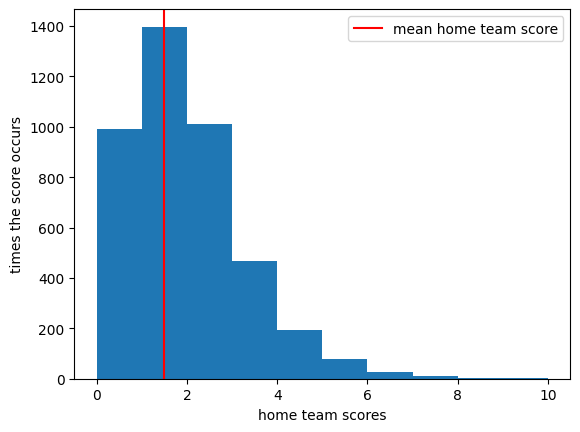

In [32]:
mean = goals_h.mean()

plt.hist(goals_h, bins='fd') 

plt.xlabel('home team scores')
plt.ylabel('times the score occurs')

plt.axvline(mean, c='r', label='mean home team score') 

plt.legend()
plt.show()

We can see that the there is a trend around the more lowwer scores(0,1,2), which is logical because the football is most of the times a lower scoring games, because of the difficulty it provides.


We can that there are some extreme values such as score of 10, 9, 8, which are occured only in 1 to 9 matches max.This could be a cause of a match between a very strong and a very weak teams, or maybe, **if we return to the assumption we made earlier about the home team advantage**, we can assump that such results can be achived only from a home teams, and the away teams are less likely to achive such results, but to see this lets see the distribution of the away teams scores:

In [33]:
# This is for the away teams scores:
goals_a = us_matches_interim['goals_a']

goals_a.value_counts()

goals_a
1    1496
0    1399
2     844
3     281
4     116
5      30
6      10
8       3
7       1
Name: count, dtype: int64

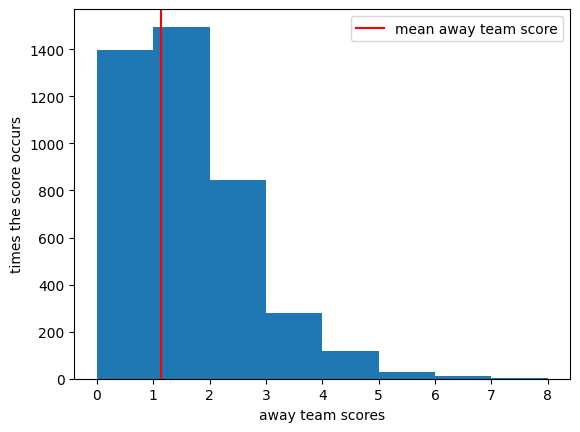

In [34]:
mean = goals_a.mean()

plt.hist(goals_a, bins='fd') 

plt.xlabel('away team scores')
plt.ylabel('times the score occurs')

plt.axvline(mean, c='r', label='mean away team score') 

plt.legend()
plt.show()

We can see that both of the histograms are more or less the same with mean around 1 and both contains some extreme values, which could be explained by many factors, such as team forma at the time, home/away match, lineups, players injuries etc, things which will analyze a in the time!

Well what I can do is to plot a simple boxplot which will clearly show the outliers:

In [35]:
min_goals_h = goals_h.min()
max_goals_h = goals_h.max()

first_quartile = np.quantile(goals_h, 0.25)
middle_quartile = np.quantile(goals_h, 0.50) # The mean value of the distribution
last_quartile = np.quantile(goals_h, 0.75)

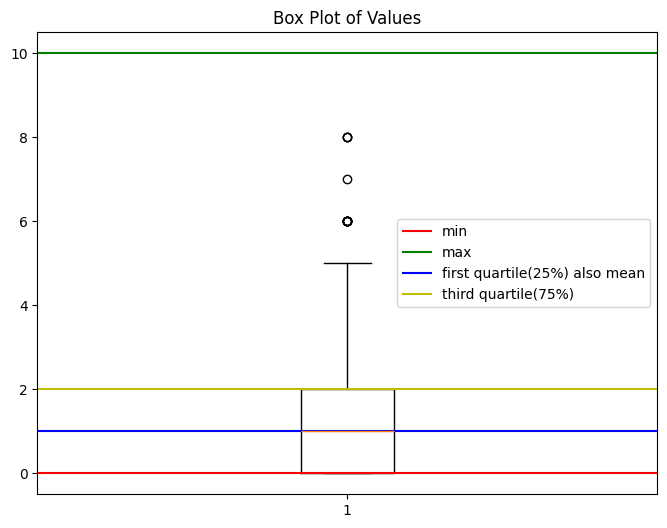

In [36]:
plt.figure(figsize =(8, 6))

plt.boxplot(goals_a)
plt.title('Box Plot of Values')

plt.axhline(min_goals_h, c='r', label='min')
plt.axhline(max_goals_h, c='g', label='max', )
plt.axhline(first_quartile, c='b', label='first quartile(25%) also mean')
plt.axhline(last_quartile, c='y', label='third quartile(75%)')

plt.legend()
plt.show()

We can clearly see where most of the values are fallen, and we can see the ouliers which are represented as the dots outside of the square!

Now lets see the same but for the away teams score, to see if there is soem visual difference:

In [37]:
min_goals_a = goals_a.min()
max_goals_a = goals_a.max()

first_quartile = np.quantile(goals_a, 0.25)
middle_quartile = np.quantile(goals_a, 0.50) # The mean value of the distribution
last_quartile = np.quantile(goals_a, 0.75)

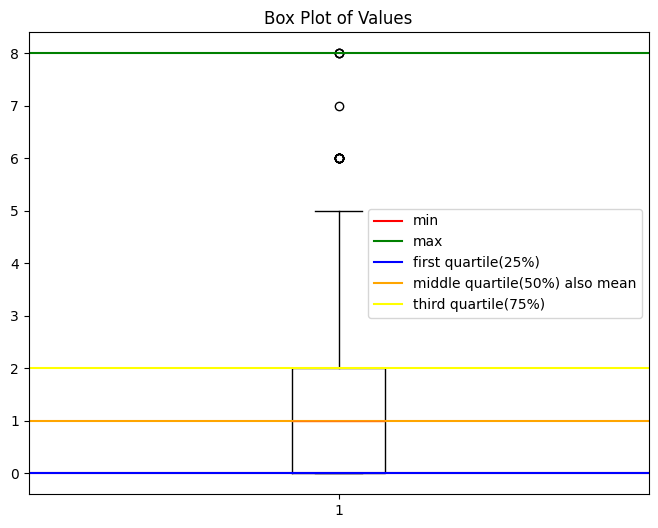

In [38]:
plt.figure(figsize =(8, 6))

plt.boxplot(goals_a)
plt.title('Box Plot of Values')

plt.axhline(min_goals_a, c='red', label='min')
plt.axhline(max_goals_a, c='green', label='max', )
plt.axhline(first_quartile, c='blue', label='first quartile(25%)')
plt.axhline(middle_quartile, c='orange', label='middle quartile(50%) also mean')
plt.axhline(last_quartile, c='yellow', label='third quartile(75%)')

plt.legend()
plt.show()

As a difference, we can see that in this box plot more values fall into the first quartile at **zero**! \
So can we support our assumption again, that the home teams score more goals, than the away teams, which leads to more wins for the home teams??**Interesting!**

One last thin I would do for this dataset is to rename the forecast columns, because currently they are little vague to what their values actually refer to.So to clarify that the **forecast_w** is the probability that home team will win the match, the **forecast_d** is the probability that the match will finish as draw and the **forecast_l** is the probability that away team will win the match.

So to make it more clear from now on, I will just rename them to: **prob_home_win**, **prob_draw** and **prob_away_win**.

SO lets do it:

In [39]:
us_matches_interim = us_matches_interim.rename(columns={"forecast_w": "prob_home_win", "forecast_d": "prob_draw", "forecast_l": "prob_away_win"})

In [40]:
us_matches_interim.columns

Index(['datetime', 'season', 'h_id', 'h_title', 'a_id', 'a_title', 'goals_h',
       'goals_a', 'xG_h', 'xG_a', 'prob_home_win', 'prob_draw',
       'prob_away_win'],
      dtype='str')

Ok now it's better!

For now I think that this is all we should do for this matches dataset.In later phrases of the project, if needed will be performed additional processes and analyses!

So in order to keep the new version of this dataset I will store it inside the interim folder, where the intermediate verisons of the datasets will be stored!

So lets do it:

In [41]:
PROJECT_ROOT = Path().resolve().parent

file_path = PROJECT_ROOT / UNDERSTAT_INTERIM_PATH / 'interim_matches_v1.parquet'
save_data(data=us_matches_interim, file_path=file_path)

The file has already been created and it contains the exact data as the original dataset!


In [42]:
us_matches_interim.head(5)

,datetime,season,h_id,h_title,a_id,a_title,goals_h,goals_a,xG_h,xG_a,prob_home_win,prob_draw,prob_away_win
id,,,,,,,,,,,,,
5826,2014-08-23 18:00:00,2014/2015,137,Malaga,147,Athletic Club,1,0,1.321070,1.141510,0.3996,0.3315,0.2689
5827,2014-08-23 20:00:00,2014/2015,138,Sevilla,146,Valencia,1,1,1.171970,1.749030,0.1984,0.2906,0.5110
5828,2014-08-23 20:00:00,2014/2015,155,Granada,139,Deportivo La Coruna,2,1,0.548351,0.379371,0.3244,0.4747,0.2009
5829,2014-08-23 22:00:00,2014/2015,208,Almeria,141,Espanyol,1,1,0.978788,0.399306,0.5100,0.3494,0.1406
5830,2014-08-24 18:00:00,2014/2015,156,Eibar,140,Real Sociedad,1,0,0.465398,0.975523,0.1580,0.3601,0.4819


---

### Now Lets proceed with the next Understat dataset which would be the **Matches shots**
<a id='understat_section_matches_shots'></a>

#### Matches Shots:

This dataset contains detailed shot data for each played match from season 2014 to 2025!

This is a very useful and important data, because this will help us understand more event level data such as shots at different situations, with specified expected probabilities of goals and more.What is more important, this data is **essential for modern football prediction models, representing a significant shift from outcome-based analysis to process-based analysis**!

One of the project objectives is to identify what "True" Team Performance actually is and this kind of data will take a big part of these analyses!
> Goals are rare and often lucky, whereas shots are more frequent and reflect better team performance. xG values are more stable and better predictors of future performance than previous goals or points.

So withput any more explanations, lets load the data and understand more about it:

In [43]:
us_matches_shots = pd.read_csv('../data/raw/understat_data/matches_shots.csv')

In [44]:
us_matches_shots

,id,minute,result,X,Y,xG,player,h_a,player_id,situation,season,shotType,match_id,h_team,a_team,h_goals,a_goals,date,player_assisted,lastAction
0,32412,10,MissedShots,0.765,0.380,0.022562,Sergi Darder,h,2621,OpenPlay,2014/2015,RightFoot,5826,Malaga,Athletic Club,1,0,2014-08-23 18:00:00,Ricardo Horta,Pass
1,32414,16,BlockedShot,0.953,0.437,0.115952,Juanmi,h,897,OpenPlay,2014/2015,RightFoot,5826,Malaga,Athletic Club,1,0,2014-08-23 18:00:00,NaN,NaN
2,32415,17,BlockedShot,0.805,0.725,0.012673,Ricardo Horta,h,2338,FromCorner,2014/2015,RightFoot,5826,Malaga,Athletic Club,1,0,2014-08-23 18:00:00,Roque Santa Cruz,HeadPass
3,32416,18,MissedShots,0.876,0.252,0.027693,Ricardo Horta,h,2338,OpenPlay,2014/2015,RightFoot,5826,Malaga,Athletic Club,1,0,2014-08-23 18:00:00,Juanmi,Pass
4,32418,29,MissedShots,0.832,0.690,0.034855,Ricardo Horta,h,2338,OpenPlay,2014/2015,RightFoot,5826,Malaga,Athletic Club,1,0,2014-08-23 18:00:00,Luis Alberto,Pass
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99186,636228,72,SavedShot,0.898,0.630,0.084902,Adrià Pedrosa,a,7174,OpenPlay,2024/2025,LeftFoot,27361,Villarreal,Sevilla,4,2,2025-05-25 14:15:00,Suso,Pass
99187,636230,75,MissedShots,0.910,0.756,0.025298,Suso,a,1129,OpenPlay,2024/2025,LeftFoot,27361,Villarreal,Sevilla,4,2,2025-05-25 14:15:00,Adrià Pedrosa,Pass
99188,636231,84,Goal,0.818,0.437,0.030608,Ramón Martínez,a,13198,OpenPlay,2024/2025,LeftFoot,27361,Villarreal,Sevilla,4,2,2025-05-25 14:15:00,Lucien Agoume,Chipped
99189,636233,90,BlockedShot,0.966,0.346,0.018303,Ramón Martínez,a,13198,OpenPlay,2024/2025,Head,27361,Villarreal,Sevilla,4,2,2025-05-25 14:15:00,Lucien Agoume,Chipped


Ok now, this time the dataset is a little big bigger, ok not little big, almost two and half times bigger, which means that will be dealing with more things, including more rows and more features(columns)!

So lets first check shape:

In [45]:
us_matches_shots.shape

(99191, 20)

It seems to be right!

Now lets see the dataset info.Are there any missing values?

In [46]:
us_matches_shots.info()

<class 'pandas.DataFrame'>
RangeIndex: 99191 entries, 0 to 99190
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               99191 non-null  int64  
 1   minute           99191 non-null  int64  
 2   result           99191 non-null  str    
 3   X                99191 non-null  float64
 4   Y                99191 non-null  float64
 5   xG               99191 non-null  float64
 6   player           99191 non-null  str    
 7   h_a              99191 non-null  str    
 8   player_id        99191 non-null  int64  
 9   situation        99191 non-null  str    
 10  season           99191 non-null  str    
 11  shotType         99191 non-null  str    
 12  match_id         99191 non-null  int64  
 13  h_team           99191 non-null  str    
 14  a_team           99191 non-null  str    
 15  h_goals          99191 non-null  int64  
 16  a_goals          99191 non-null  int64  
 17  date             99191 

Well what I can see is that this time the dataset contains some null values into the **player_assisted and lastAction columns**.Well what I can assump as the reason for that is that, in some situations there is just not visiable or clear assist that have been made before the shot.For example, a player may have received the ball after a ricochet or after a block from a shot and all sorts of specific situations.

In this case, this will not be a very big problem, because it is not so important who had give the ball to the player that have shot it, but what is more important from what situation the shot have happened, what was the result from the shot, who have made it and most importantly what was the probability of that shot to end up in a goal!For all of these questions we have more than enough data!

Now the to begin with I will try to see from where this missing values could have come from.I assump that most of them are a cause of a specific situation that has occured before the shot was taken, so lets see what types of situations we have:

In [47]:
us_matches_shots['situation'].unique()

<ArrowStringArray>
['OpenPlay', 'FromCorner', 'Penalty', 'SetPiece', 'DirectFreekick']
Length: 5, dtype: str

Well there are five situations which could have happend before the shots which are: **OpenPLay, FromCorner, Penalty, SetPiece and DirectFreekick**.So lets check is there is any specific situation which could have caused the missing values.To do that I will expect the rows with the missing values and see if there is certain situation that is occiring more times!

In [48]:
na_matches = us_matches_shots[
    (us_matches_shots['player_assisted'].isna()) |
    (us_matches_shots['lastAction'].isna())
][['result', 'shotType', 'situation', 'player_assisted', 'lastAction']]

na_matches

,result,shotType,situation,player_assisted,lastAction
1,BlockedShot,RightFoot,OpenPlay,NaN,NaN
5,SavedShot,RightFoot,Penalty,NaN,Standard
6,Goal,RightFoot,SetPiece,NaN,Rebound
7,MissedShots,RightFoot,OpenPlay,NaN,BallTouch
9,BlockedShot,LeftFoot,OpenPlay,NaN,NaN
...,...,...,...,...,...
99145,BlockedShot,RightFoot,OpenPlay,NaN,Rebound
99150,SavedShot,RightFoot,DirectFreekick,NaN,Standard
99157,BlockedShot,RightFoot,FromCorner,NaN,Rebound
99159,Goal,LeftFoot,FromCorner,NaN,Rebound


Lets group them by situation:

In [49]:
na_matches.value_counts(subset='situation')

situation
OpenPlay          15340
DirectFreekick     4318
FromCorner         4292
SetPiece           2027
Penalty            1344
Name: count, dtype: int64

Most of them are from an open play, which can mean many things!

##### I have expected that most of them will have been from **Set Piece** situation which could have occured from players that have made a shot, which shot had hit the post, and immediately another shot has made.In such situations the first action is not considered as an "assist" for the second shot!

Well we can clearly see that this is not the case, so based on some resources, these could be the reasosn for such scenarios:

**Individual Individual Action or Solo Run**: 
- The player taking the shot may have dribbled past defenders, stolen the ball, or created the opportunity entirely on their own, meaning no teammate provided a direct pass leading to the shot.

**Loose Ball, Rebound, or Error**: 
- The shot may have been taken following a loose ball, a defensive error, a rebound off a defender or goalkeeper, or a loose ball intercepted by the shooter.

**Dribbling or Carrying the Ball**:
- A player might carry the ball over a significant distance before shooting. Because they have held the ball for an extended period, the original passer is no longer credited with the "last action," and the shooter's dribble is considered the primary event.

**Interception or Blocked Pass**: 
- If a teammate tries to pass to the shooter but the ball hits a defender, is deflected, or takes a weird bounce before the shot, the system may not record it as a clean assist.

**Data Recording and "Key Pass" Definitions**: 
- According to many data providers (like Opta), an assist is only recorded for the last pass that directly leads to a shot. If there is a noticeable pause, a significant dribble, or a chaotic sequence between the last pass and the shot, the "assist" is often not recorded.

**Set Piece Scenarios (Own Rebound)**: 
- In cases of free kicks or penalties, if a player shoots, hits the post, and immediately shoots again, the first action is not considered an "assist" for the second shot

Actually, one thing that could tell us, what could have caused the player assisted to be nan, is the last action before the shot was taken!

So lets see what are the possible values that the **lastAction** column contains and expect them:

In [50]:
na_matches['lastAction'].unique()

<ArrowStringArray>
[              nan,        'Standard',         'Rebound',       'BallTouch',
          'TakeOn',    'BallRecovery',    'Dispossessed',          'Aerial',
    'Interception',            'Foul',       'Challenge',   'CornerAwarded',
       'Clearance',          'Tackle',            'Goal',  'SubstitutionOn',
       'GoodSkill',     'OffsidePass',            'Save',     'BlockedPass',
            'Card',    'PenaltyFaced',             'End',    'KeeperPickup',
 'FormationChange',           'Start',    'ChanceMissed',         'Smother',
           'Error',            'Pass', 'OffsideProvoked']
Length: 31, dtype: str

Well from what I know as a person which has played football, the only actions which are logical to have happend as an assist before the shot are the: **Pass** - a normal pass, **Standard** - a statical situation(corners, free kicks),**CornerAwarded** - corners, **Aerial** - air duel – First ball won which could had caused a head assist, **Rebound** - this more specific because is could have occured from either a block shot, a miss and return of the ball and from a team player.

This are the values that are most logical to have happened as a assists before the shot, all the other are either solo performans or just actions which are not logical to have happened as an assists like: BallRecovery, Tackle, Clearance etc!

So now lets see if the logical assist values are occuring most of times, when there is no defined assist player:

In [51]:
missing_players_assisted = us_matches_shots[us_matches_shots['player_assisted'].isna()][
    ['result', 'shotType', 'situation', 'player_assisted', 'lastAction']
]

missing_players_assisted

,result,shotType,situation,player_assisted,lastAction
1,BlockedShot,RightFoot,OpenPlay,NaN,NaN
5,SavedShot,RightFoot,Penalty,NaN,Standard
6,Goal,RightFoot,SetPiece,NaN,Rebound
7,MissedShots,RightFoot,OpenPlay,NaN,BallTouch
9,BlockedShot,LeftFoot,OpenPlay,NaN,NaN
...,...,...,...,...,...
99145,BlockedShot,RightFoot,OpenPlay,NaN,Rebound
99150,SavedShot,RightFoot,DirectFreekick,NaN,Standard
99157,BlockedShot,RightFoot,FromCorner,NaN,Rebound
99159,Goal,LeftFoot,FromCorner,NaN,Rebound


In [52]:
missing_players_assisted.value_counts(subset='lastAction')

lastAction
Standard           5662
Rebound            3437
Aerial             1744
BallRecovery       1544
TakeOn             1380
BallTouch           552
Dispossessed        453
Tackle              149
Interception         67
CornerAwarded        67
BlockedPass          58
Foul                 55
Challenge            35
Clearance            33
Goal                 23
Save                 17
End                  13
Card                 11
OffsidePass          10
SubstitutionOn        6
Start                 4
KeeperPickup          3
FormationChange       2
GoodSkill             1
PenaltyFaced          1
ChanceMissed          1
Smother               1
Error                 1
Pass                  1
OffsideProvoked       1
Name: count, dtype: int64

In [53]:
us_matches_shots_interim = us_matches_shots.copy()

us_matches_shots_interim

,id,minute,result,X,Y,xG,player,h_a,player_id,situation,season,shotType,match_id,h_team,a_team,h_goals,a_goals,date,player_assisted,lastAction
0,32412,10,MissedShots,0.765,0.380,0.022562,Sergi Darder,h,2621,OpenPlay,2014/2015,RightFoot,5826,Malaga,Athletic Club,1,0,2014-08-23 18:00:00,Ricardo Horta,Pass
1,32414,16,BlockedShot,0.953,0.437,0.115952,Juanmi,h,897,OpenPlay,2014/2015,RightFoot,5826,Malaga,Athletic Club,1,0,2014-08-23 18:00:00,NaN,NaN
2,32415,17,BlockedShot,0.805,0.725,0.012673,Ricardo Horta,h,2338,FromCorner,2014/2015,RightFoot,5826,Malaga,Athletic Club,1,0,2014-08-23 18:00:00,Roque Santa Cruz,HeadPass
3,32416,18,MissedShots,0.876,0.252,0.027693,Ricardo Horta,h,2338,OpenPlay,2014/2015,RightFoot,5826,Malaga,Athletic Club,1,0,2014-08-23 18:00:00,Juanmi,Pass
4,32418,29,MissedShots,0.832,0.690,0.034855,Ricardo Horta,h,2338,OpenPlay,2014/2015,RightFoot,5826,Malaga,Athletic Club,1,0,2014-08-23 18:00:00,Luis Alberto,Pass
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99186,636228,72,SavedShot,0.898,0.630,0.084902,Adrià Pedrosa,a,7174,OpenPlay,2024/2025,LeftFoot,27361,Villarreal,Sevilla,4,2,2025-05-25 14:15:00,Suso,Pass
99187,636230,75,MissedShots,0.910,0.756,0.025298,Suso,a,1129,OpenPlay,2024/2025,LeftFoot,27361,Villarreal,Sevilla,4,2,2025-05-25 14:15:00,Adrià Pedrosa,Pass
99188,636231,84,Goal,0.818,0.437,0.030608,Ramón Martínez,a,13198,OpenPlay,2024/2025,LeftFoot,27361,Villarreal,Sevilla,4,2,2025-05-25 14:15:00,Lucien Agoume,Chipped
99189,636233,90,BlockedShot,0.966,0.346,0.018303,Ramón Martínez,a,13198,OpenPlay,2024/2025,Head,27361,Villarreal,Sevilla,4,2,2025-05-25 14:15:00,Lucien Agoume,Chipped


First things first, lets set the index of the the dataset to be the id column.

But before setting it to be the key of the dataset, I should ensure that it is unique!

In [54]:
len(us_matches_shots_interim['id'].unique()) == len(us_matches_shots_interim)

True

Ok all of the ids are fully unique, so I am free to set the id as the index of the dataset:

In [55]:
us_matches_shots_interim = us_matches_shots_interim.set_index(keys='id')

In [56]:
us_matches_shots_interim.head(1)

,minute,result,X,Y,xG,player,h_a,player_id,situation,season,shotType,match_id,h_team,a_team,h_goals,a_goals,date,player_assisted,lastAction
id,,,,,,,,,,,,,,,,,,,
32412,10,MissedShots,0.765,0.38,0.022562,Sergi Darder,h,2621,OpenPlay,2014/2015,RightFoot,5826,Malaga,Athletic Club,1,0,2014-08-23 18:00:00,Ricardo Horta,Pass


Now lets remove the player assisted column, as we have agreed!

In [57]:
us_matches_shots_interim = us_matches_shots_interim.drop('player_assisted', axis=1)

In [58]:
print('player_assisted' in us_matches_shots_interim.columns)

False


So as I have said, the best thing that could be done to the nan values of the lastAction column, is to just set them as unidentified.It will be totally wrong if I remove the column, becasue this data may be useful for future analyses!One approach that could be considered in such situations is to fill in the missing values with the mean or the more poplar values like the Standard last action for example!But for me this would be a wrong choice because these values are not specified for a reason, not because of a random behavior(I strongly suppose that is not random!), so it would be an kind of a bias if we add certain values to places which are just unidentified, because of a specific reason!

What some sources says about this approach is:
> Replacing NaN values with the mean, median, or mode (most popular) is a form of imputation that definitely introduces bias into a dataset. While this technique is a common, fast, and necessary step for many machine learning algorithms that cannot handle missing data, it alters the data's fundamental structure, often producing biased results in subsequent analyses

So I will go with the unidentified approach and just the missing values to unidentified, just because this is what they are!

lets do it:

In [59]:
# Only fill NaN with 'unidentified' for the lastAction column
last_action_col = us_matches_shots_interim[['lastAction']].columns

us_matches_shots_interim[last_action_col] = us_matches_shots_interim[last_action_col].fillna('unidentified')

Lets check if everything is ok now:

In [60]:
us_matches_shots_interim.info()

<class 'pandas.DataFrame'>
Index: 99191 entries, 32412 to 636235
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   minute      99191 non-null  int64  
 1   result      99191 non-null  str    
 2   X           99191 non-null  float64
 3   Y           99191 non-null  float64
 4   xG          99191 non-null  float64
 5   player      99191 non-null  str    
 6   h_a         99191 non-null  str    
 7   player_id   99191 non-null  int64  
 8   situation   99191 non-null  str    
 9   season      99191 non-null  str    
 10  shotType    99191 non-null  str    
 11  match_id    99191 non-null  int64  
 12  h_team      99191 non-null  str    
 13  a_team      99191 non-null  str    
 14  h_goals     99191 non-null  int64  
 15  a_goals     99191 non-null  int64  
 16  date        99191 non-null  str    
 17  lastAction  99191 non-null  str    
dtypes: float64(3), int64(5), str(10)
memory usage: 23.2 MB


Now there are no more missing values and everything is filled with the right values!

Ok now what I want to ensure is that there are no duplicates among the dataset.As duplicate I consider an observation, with the same two teams, same date and same minute, occuring more than ones!It is not possible a shot to occur more than ones, in one date, with the same teams and in the same minute.Its just not right, so lets confirm that!

Well is seems that my assumptions are wrong, or just these actions like Standard, Rebound and Aerial which I have told that are less likely to be last actions before the shots without assist, but, again, these values could have also be considered to be a cause from any exernal factors wihtout any clear involve of a player!

However what I think, which would be safe and no-probelmatic, is that the column **player assisted** can be **removed** and for the nan values of the lastAction column can be setted as **unidentified**.This would be the right approach for this situation, because the an info which specifies the player that have made the assist of the shot is not so important and relevant to the datasets itself and for the objectives of the project, so this column can be freely removed!

But before that I should make a copy of the dataset, so that the raw data to stayed untouched, and a new cleaned version to be created!

In [61]:
dupes = us_matches_shots_interim.duplicated(
    subset=['minute', 'h_team', 'a_team', 'date']
)

dupes.any()

np.True_

##### Well, there are duplicates, and this is actually logical!I was not right when I said that it is impossible to have a shot occured more than ones, in the same minute, in the same date with the same teams, because if we think a little, a player could have made a shot, which could have been saved by the goalkeeper, and than immediatly the player could have made another shot!And any kind of such situations which are abosutely possible!

So in this situation it could not be clearly defined a criteria by which a duplicates can be found, so I will just get some of the duplicates and see what could be the varying part in them, in order to maybe create a duplicate criteria!

Lets first get the ids of the duplicates:

In [62]:
duplicates = dupes[dupes.values == True]

print(len(duplicates))

# Getting a random one:
random_duplicate_index = duplicates.index[28]
random_duplicate_index

11327


np.int64(32605)

In [63]:
duplicate_match_shot_situation = us_matches_shots_interim.loc[random_duplicate_index]

duplicate_match_shot_situation

minute                         66
result                MissedShots
X                           0.986
Y                           0.418
xG                       0.068985
player           Roque Santa Cruz
h_a                             a
player_id                    2341
situation              FromCorner
season                  2014/2015
shotType                     Head
match_id                     5837
h_team                   Valencia
a_team                     Malaga
h_goals                         3
a_goals                         0
date          2014-08-29 21:00:00
lastAction                  Cross
Name: 32605, dtype: object

Lets see which are his duplicates:

In [64]:
us_matches_shots_interim[
    (us_matches_shots_interim['minute'] == duplicate_match_shot_situation.minute) &
    (us_matches_shots_interim['h_team'] == duplicate_match_shot_situation.h_team) &
    (us_matches_shots_interim['a_team'] == duplicate_match_shot_situation.a_team) &
    (us_matches_shots_interim['date'] == duplicate_match_shot_situation.date)
]

,minute,result,X,Y,xG,player,h_a,player_id,situation,season,shotType,match_id,h_team,a_team,h_goals,a_goals,date,lastAction
id,,,,,,,,,,,,,,,,,,
32604,66,SavedShot,0.907,0.577,0.353284,Samu Castillejo,a,2303,OpenPlay,2014/2015,LeftFoot,5837,Valencia,Malaga,3,0,2014-08-29 21:00:00,Interception
32605,66,MissedShots,0.986,0.418,0.068985,Roque Santa Cruz,a,2341,FromCorner,2014/2015,Head,5837,Valencia,Malaga,3,0,2014-08-29 21:00:00,Cross


One thing that has come to my mind is to try the following criteria: **match_id + player_id + minute + X + Y + shotType**: A specific player, in a specific match, at a specific location and time, making the same type of action.

This, should be something interesting to check in:

In [65]:
dupes = us_matches_shots_interim.duplicated(
    subset=['match_id', 'player_id', 'minute', 'X', 'Y', 'shotType']
)

duplicates = dupes[dupes.values == True]
print(duplicates)

# Getting a random one:
random_duplicate_index = duplicates.index[0]
random_duplicate_index

id
32904     True
33787     True
35731     True
189074    True
202119    True
221387    True
313066    True
329231    True
337816    True
364552    True
dtype: bool


np.int64(32904)

In [66]:
duplicate_match_shot_situation = us_matches_shots_interim.loc[random_duplicate_index]

duplicate_match_shot_situation

minute                         86
result                BlockedShot
X                           0.755
Y                           0.577
xG                        0.02665
player             Gonzalo Castro
h_a                             a
player_id                    2342
situation              FromCorner
season                  2014/2015
shotType                 LeftFoot
match_id                     5790
h_team                 Celta Vigo
a_team              Real Sociedad
h_goals                         2
a_goals                         2
date          2014-09-13 21:00:00
lastAction                Rebound
Name: 32904, dtype: object

In [67]:
us_matches_shots_interim[
    (us_matches_shots_interim['minute'] == duplicate_match_shot_situation.minute) &
    (us_matches_shots_interim['h_team'] == duplicate_match_shot_situation.h_team) &
    (us_matches_shots_interim['a_team'] == duplicate_match_shot_situation.a_team) &
    (us_matches_shots_interim['date'] == duplicate_match_shot_situation.date)
]

,minute,result,X,Y,xG,player,h_a,player_id,situation,season,shotType,match_id,h_team,a_team,h_goals,a_goals,date,lastAction
id,,,,,,,,,,,,,,,,,,
32903,86,BlockedShot,0.755,0.577,0.018322,Gonzalo Castro,a,2342,FromCorner,2014/2015,LeftFoot,5790,Celta Vigo,Real Sociedad,2,2,2014-09-13 21:00:00,unidentified
32904,86,BlockedShot,0.755,0.577,0.026650,Gonzalo Castro,a,2342,FromCorner,2014/2015,LeftFoot,5790,Celta Vigo,Real Sociedad,2,2,2014-09-13 21:00:00,Rebound


Well even with this criteria, there are some duplicates!**Woll!**

This starts to feel like real invalid duplicates which have been added by mistake in the dataset, but I cannot be fully sure, because from what I know, it is theoretically possible for a specific player to make the same type of shot from the same location in the same match, but having it occur at the exact same time (down to the second) is virtually impossible in a live, physical sport - This is something I cannot test because the dataset does not provide the full exact time including the seconds at which theb shot was taken, so I will consider this a limit of the dataset which I cannot control!

For now I will left the things as they are, just because I cannot be fully sure if they are wrong or not.I just dont have the required data to check that!

Ok, now lets proceed. 

The next thing that I am going to do is to remove some useless columns, if there are some!

If we look at the columns of the dataset:

In [68]:
us_matches_shots_interim.columns

Index(['minute', 'result', 'X', 'Y', 'xG', 'player', 'h_a', 'player_id',
       'situation', 'season', 'shotType', 'match_id', 'h_team', 'a_team',
       'h_goals', 'a_goals', 'date', 'lastAction'],
      dtype='str')

I can identify two columns which dont vary across the different matches, and what I mean by this is that they stay the same during the whole matches!

These are the **h_goals and a_goals** columns.These columns represent the final score of the home and the way teams! These two don't change per situation but are defined as the final results of the matches for each different shot situation!

> The important thing is that these columns are actually useless in the current dataset, because they are not relevant to the data of the dataset, which is about shots, their different situations, types and their predictions!These two columns are contained in the [Matches](#understat_section_matches), and this is where they should be as an essential data at match level stats, but for this one, for this one they are useless and don't provide any important info that could be in use of the analyses related to this dataset!

So what I will do, is that I will remove these two columns!

In [69]:
us_matches_shots_interim = us_matches_shots_interim.drop(columns=['h_goals', 'a_goals'])

In [70]:
print('h_goals' in us_matches_shots_interim.columns)
print('a_goals' in us_matches_shots_interim.columns)

False
False


In [71]:
us_matches_shots_interim.columns

Index(['minute', 'result', 'X', 'Y', 'xG', 'player', 'h_a', 'player_id',
       'situation', 'season', 'shotType', 'match_id', 'h_team', 'a_team',
       'date', 'lastAction'],
      dtype='str')

---

##### Ok the next thing I will do is that I will try to optimize the memory usage of the dataset, just because the dataset is quite big and it will be very useful if it can be reduced from memory a little!

But before that lets see if there are any problems with the columns types:

In [72]:
us_matches_shots_interim.dtypes

minute          int64
result            str
X             float64
Y             float64
xG            float64
player            str
h_a               str
player_id       int64
situation         str
season            str
shotType          str
match_id        int64
h_team            str
a_team            str
date              str
lastAction        str
dtype: object

Well, again as with the matches dataset, there is a problem with the type of the date.The date column is represented as a sring which is totally wrong and it should be casted to a type of datetime forsure!

So lets do this, by using the `convert_string_to_datetime` function from the `src/football_betting_analysis/data/` directory, which accepts as parameters the **string column** to be transformed to **datetime**, the **datetime format** that should be preserved across the values of the column and an **errors parameter** which setted to **raise**, raises an exception if the column is with inconsistent format and cannot be casted to the specified format; **coerce**, which will fill NaT values to the ones, whose formats does not corresponds to the specified and the **ignore** which will return the original column without any transformations, if there are inconsistencies across the formats of the values!

The functiom ensures that all of the values of the column are with inconsistent formats and all of the values of column are transoformed to the type of datetime with the specified format!

So lets do it:

In [73]:
us_matches_shots_interim['date'] = convert_string_to_datetime(us_matches_shots_interim['date'], '%Y-%m-%d %H:%M:%S')

In [74]:
us_matches_shots_interim.dtypes

minute                 int64
result                   str
X                    float64
Y                    float64
xG                   float64
player                   str
h_a                      str
player_id              int64
situation                str
season                   str
shotType                 str
match_id               int64
h_team                   str
a_team                   str
date          datetime64[us]
lastAction               str
dtype: object

Well now everything seems to be fine with the data types!

So lets return to the main objective which is the memory usage reduction.The memory reduction is a technique which reduces the memory usage of dataset, by converting certain columns types to ones which takes less memory.For example an integer column which contains not very big values has a data type of int64, but actaully the column could use the int32 which takes less memory and makes the dataset more efficient!

So, I will do that by using the `optimize_dataframe_memory` from the `src/football_betting_anaysis/data` which is a function which Optimize memory usage of a DataFrame by converting columns to more efficient data types.
    
The function accepts a data frame on which to perform the optimization! \
It analyzes each column and applies appropriate optimizations:
- Integer columns: Converts to smallest possible int type (int8, int16, int32, int64)
- Float columns: Downcast to the smallest float type if precision allows
- Object/String columns: Converts to category if cardinality is low (< 50% unique values)

So lets do it:

In [75]:
us_matches_shots_interim = optimize_dataframe_memory(us_matches_shots_interim)

Initial Memory Usage: 21.86 MB
Final Memory Usage: 6.12 MB
Memory Reduction: 72.00%

Optimized Data Types:
minute                  int8
result              category
X                    float32
Y                    float32
xG                   float32
player              category
h_a                 category
player_id              int16
situation           category
season              category
shotType            category
match_id               int16
h_team              category
a_team              category
date          datetime64[us]
lastAction          category
dtype: object


The summary clearly shows the memory reduction, but lets see it with the info function:

In [76]:
us_matches_shots_interim.info()

<class 'pandas.DataFrame'>
Index: 99191 entries, 32412 to 636235
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   minute      99191 non-null  int8          
 1   result      99191 non-null  category      
 2   X           99191 non-null  float32       
 3   Y           99191 non-null  float32       
 4   xG          99191 non-null  float32       
 5   player      99191 non-null  category      
 6   h_a         99191 non-null  category      
 7   player_id   99191 non-null  int16         
 8   situation   99191 non-null  category      
 9   season      99191 non-null  category      
 10  shotType    99191 non-null  category      
 11  match_id    99191 non-null  int16         
 12  h_team      99191 non-null  category      
 13  a_team      99191 non-null  category      
 14  date        99191 non-null  datetime64[us]
 15  lastAction  99191 non-null  category      
dtypes: category(9), datetime64[us](1)

##### We can see the huge memory reduction we have made!This is really really important for the dataset, because now the columns takes much less memory and everything will perform much more fast and efficient!

Now the next thing I would do is to check for any wrong or invalid values across the text content columns of the datasets.This refers to values with leading or trailing white spaces, incorrect encoding symbols and any kind of invalid and potentially problematic behaviour!

As I have did with the Matches dataset, I will use the `clean_text_values` function at the following directory: `scr/football_betting_analysis/data`, which function simply cleans a pandas Series or list-like of text values from any of the listed above features!

I will do that by first get all of the category columns of the dataset(Category because I have transoformed all of the string columns into a category type ones) and than perform the function for each of the columns!

Lets do it:

In [77]:
# Getting all of the text columns:
category_cols = us_matches_shots_interim.select_dtypes(include=['category']).columns

# The clean_text_values should be fixed to work with category type columns too!
us_matches_shots_interim[category_cols] = us_matches_shots_interim[category_cols].apply(
    clean_text_values
)

In [78]:
us_matches_shots_interim

,minute,result,X,Y,xG,player,h_a,player_id,situation,season,shotType,match_id,h_team,a_team,date,lastAction
id,,,,,,,,,,,,,,,,
32412,10,MissedShots,0.765,0.380,0.022562,Sergi Darder,h,2621,OpenPlay,2014/2015,RightFoot,5826,Malaga,Athletic Club,2014-08-23 18:00:00,Pass
32414,16,BlockedShot,0.953,0.437,0.115952,Juanmi,h,897,OpenPlay,2014/2015,RightFoot,5826,Malaga,Athletic Club,2014-08-23 18:00:00,unidentified
32415,17,BlockedShot,0.805,0.725,0.012673,Ricardo Horta,h,2338,FromCorner,2014/2015,RightFoot,5826,Malaga,Athletic Club,2014-08-23 18:00:00,HeadPass
32416,18,MissedShots,0.876,0.252,0.027693,Ricardo Horta,h,2338,OpenPlay,2014/2015,RightFoot,5826,Malaga,Athletic Club,2014-08-23 18:00:00,Pass
32418,29,MissedShots,0.832,0.690,0.034855,Ricardo Horta,h,2338,OpenPlay,2014/2015,RightFoot,5826,Malaga,Athletic Club,2014-08-23 18:00:00,Pass
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
636228,72,SavedShot,0.898,0.630,0.084902,Adrià Pedrosa,a,7174,OpenPlay,2024/2025,LeftFoot,27361,Villarreal,Sevilla,2025-05-25 14:15:00,Pass
636230,75,MissedShots,0.910,0.756,0.025298,Suso,a,1129,OpenPlay,2024/2025,LeftFoot,27361,Villarreal,Sevilla,2025-05-25 14:15:00,Pass
636231,84,Goal,0.818,0.437,0.030608,Ramón Martínez,a,13198,OpenPlay,2024/2025,LeftFoot,27361,Villarreal,Sevilla,2025-05-25 14:15:00,Chipped


Everything seems to be fine, but lets see if the category columns have preserved and also is the memory usage the same:

In [79]:
us_matches_shots_interim.info()

<class 'pandas.DataFrame'>
Index: 99191 entries, 32412 to 636235
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   minute      99191 non-null  int8          
 1   result      99191 non-null  category      
 2   X           99191 non-null  float32       
 3   Y           99191 non-null  float32       
 4   xG          99191 non-null  float32       
 5   player      99191 non-null  category      
 6   h_a         99191 non-null  category      
 7   player_id   99191 non-null  int16         
 8   situation   99191 non-null  category      
 9   season      99191 non-null  category      
 10  shotType    99191 non-null  category      
 11  match_id    99191 non-null  int16         
 12  h_team      99191 non-null  category      
 13  a_team      99191 non-null  category      
 14  date        99191 non-null  datetime64[us]
 15  lastAction  99191 non-null  category      
dtypes: category(9), datetime64[us](1)

##### Ok now, after that we had optimize the memory usage, cleaned and fix the text/category columns, fix the data types, check for duplicates, deal with the missing values, I think that the dataset is actually overall cleaned and ready to be saved into the interim dir!

But before that I would like to rename some columns and also fix their order!
So the first column which seems vague to me is the **result** column.To what kind of result the column refers to?It is just not very clear!So I will rename this column to **shot_result**.The next column, **shotType**, this time, is clear described, but does not follow the **snake_case** which is a standard way to name columns in pandas data frames, so what I will do is to just rename it to: **shot_type**.The same goes for the **lastAction** column, which I will rename to **last_action**!

> One thing which is really important when cleaning datasets, is to make them with **consistent column names**!This means that columns which will be used later for **merging** maybe, should be named in one way, so that everything is more clear and easy to work with!

So in order to follow this practice what I will is to rename the **date** column to **datetime**, because this is the way that the date type column is named into the **Matches** dateset, and also the name **datetime** is more clear and descriptive because the column **does not contain only date but also and time**!The other two things that should be renamed are the **h_team and the a_team** columns, which in the **Matches** dataset are named **h_title and a_title**.I cannot say which name fits better for these column, but again in order to follow consistency, I will rename them to **h_title and a_title**!

So after that we explained what we will be renameing and why lets actually do it:

In [80]:
us_matches_shots_interim = us_matches_shots_interim.rename(
    columns={'result': 'shot_result', 'shotType': 'shot_type', 'lastAction': 'last_action', 'date': 'datetime', 'h_team': 'h_title', 'a_team': 'a_title'}
)

In [81]:
us_matches_shots_interim.columns

Index(['minute', 'shot_result', 'X', 'Y', 'xG', 'player', 'h_a', 'player_id',
       'situation', 'season', 'shot_type', 'match_id', 'h_title', 'a_title',
       'datetime', 'last_action'],
      dtype='str')

Now it is much better!

##### And the last thing I would do as a cleaning for this dataset is to reorder its columns.I will just order them in a much more consistent way which is much more easier to be understand when you look at it!

So lets do it:

In [82]:
# df = df[['колона3', 'колона1', 'колона2']]
us_matches_shots_interim = us_matches_shots_interim[
    [
        'match_id',
        'season',
        'datetime', 
        'minute', 
        'situation',
        'X',
        'Y',
        'shot_type', 
        'shot_result', 
        'last_action', 
        'xG', 
        'h_title', 
        'a_title',
        'player',
        'player_id',
        'h_a'
    ]
]

In [83]:
us_matches_shots_interim.columns

Index(['match_id', 'season', 'datetime', 'minute', 'situation', 'X', 'Y',
       'shot_type', 'shot_result', 'last_action', 'xG', 'h_title', 'a_title',
       'player', 'player_id', 'h_a'],
      dtype='str')

OK now everything is just perfect and good to go!

In [84]:
us_matches_shots_interim

,match_id,season,datetime,minute,situation,X,Y,shot_type,shot_result,last_action,xG,h_title,a_title,player,player_id,h_a
id,,,,,,,,,,,,,,,,
32412,5826,2014/2015,2014-08-23 18:00:00,10,OpenPlay,0.765,0.380,RightFoot,MissedShots,Pass,0.022562,Malaga,Athletic Club,Sergi Darder,2621,h
32414,5826,2014/2015,2014-08-23 18:00:00,16,OpenPlay,0.953,0.437,RightFoot,BlockedShot,unidentified,0.115952,Malaga,Athletic Club,Juanmi,897,h
32415,5826,2014/2015,2014-08-23 18:00:00,17,FromCorner,0.805,0.725,RightFoot,BlockedShot,HeadPass,0.012673,Malaga,Athletic Club,Ricardo Horta,2338,h
32416,5826,2014/2015,2014-08-23 18:00:00,18,OpenPlay,0.876,0.252,RightFoot,MissedShots,Pass,0.027693,Malaga,Athletic Club,Ricardo Horta,2338,h
32418,5826,2014/2015,2014-08-23 18:00:00,29,OpenPlay,0.832,0.690,RightFoot,MissedShots,Pass,0.034855,Malaga,Athletic Club,Ricardo Horta,2338,h
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
636228,27361,2024/2025,2025-05-25 14:15:00,72,OpenPlay,0.898,0.630,LeftFoot,SavedShot,Pass,0.084902,Villarreal,Sevilla,Adrià Pedrosa,7174,a
636230,27361,2024/2025,2025-05-25 14:15:00,75,OpenPlay,0.910,0.756,LeftFoot,MissedShots,Pass,0.025298,Villarreal,Sevilla,Suso,1129,a
636231,27361,2024/2025,2025-05-25 14:15:00,84,OpenPlay,0.818,0.437,LeftFoot,Goal,Chipped,0.030608,Villarreal,Sevilla,Ramón Martínez,13198,a


### Now lets store the cleaned dataset into a new file into the data/interim directory!

In [85]:
PROJECT_ROOT = Path().resolve().parent

file_path = PROJECT_ROOT / UNDERSTAT_INTERIM_PATH / 'interim_matches_shots_v1.parquet'
save_data(data=us_matches_shots_interim, file_path=file_path)

The file has already been created and it contains the exact data as the original dataset!


In [86]:
us_matches_shots_interim.head(5)

,match_id,season,datetime,minute,situation,X,Y,shot_type,shot_result,last_action,xG,h_title,a_title,player,player_id,h_a
id,,,,,,,,,,,,,,,,
32412,5826,2014/2015,2014-08-23 18:00:00,10,OpenPlay,0.765,0.380,RightFoot,MissedShots,Pass,0.022562,Malaga,Athletic Club,Sergi Darder,2621,h
32414,5826,2014/2015,2014-08-23 18:00:00,16,OpenPlay,0.953,0.437,RightFoot,BlockedShot,unidentified,0.115952,Malaga,Athletic Club,Juanmi,897,h
32415,5826,2014/2015,2014-08-23 18:00:00,17,FromCorner,0.805,0.725,RightFoot,BlockedShot,HeadPass,0.012673,Malaga,Athletic Club,Ricardo Horta,2338,h
32416,5826,2014/2015,2014-08-23 18:00:00,18,OpenPlay,0.876,0.252,RightFoot,MissedShots,Pass,0.027693,Malaga,Athletic Club,Ricardo Horta,2338,h
32418,5826,2014/2015,2014-08-23 18:00:00,29,OpenPlay,0.832,0.690,RightFoot,MissedShots,Pass,0.034855,Malaga,Athletic Club,Ricardo Horta,2338,h


---

## Ok now lets proceed with the next dataset which is the Players dataset

<a id={#understat_section_players}></a>

## Players

The players dataset contains a **induvidual players specific** data about each player of each team for every season from 2014 to 2025!

Now, one thing which we should ask ourselves is: What this data will give to the project and is it going to get into use to the main objective of the project, **the creation of a statistical predictive model** and not only that, but also how this will happen?

> Well what I can say is that **individual player statistic data**, specifically, advanced metrics like **Expected Goals (xG), Expected Assists (xA)**, and defensive contribution metrics, significantly enhance football predictive models by providing a more precise understanding of what team quality actually is, rathre than just mere goal/win counts!

These metrics allow models to move beyond evaluating a team by its past results (which can be misleading due to luck) to evaluating them by the underlying quality of chances created and conceded

##### How Player Metrics Enhance Predictive Models:
**Separating Performance from Luck**: 
- Traditional stats (goals/wins) are volatile. xG/xA measure the probability of a shot or pass resulting in a goal based on historical data, revealing if a player is consistently creating high-quality opportunities or overperforming based on luck.

**Player-Dependent xG Corrections (pdxgc)**: 
- Standard xG treats all players as average finishers. By incorporating a player’s historical conversion rate (pdxgc), models can adjust xG values, leading to better predictions, especially for teams with high-quality finishers.

**Dynamic Form Tracking**: 
- Instead of season-long averages, models can use recent "per 90 minutes" player metrics to reflect current fitness and form, which is crucial for predicting the next match.

So we can see that this data can really influence the predictions of the models and can be very useful, of course only if used in the right way!

After this short intro, lets proceed to the data understanding!

As you may already noticed, I am following a simple data cleaning process which includes the following steps:
- Get a first look at the data and understand it as it is possible
- Check for missing values
- Check for duplicates (This also refers to invalid and unlogical values)
- Fix the data types (This mainly refers to the fixing of the highly incorrect and incompatible data types, e.g. int value in a str type column)
- Optimize the memory usage (This is about casting certain columns type to ones with sizes, which leads to the reduction of memory usage across the dataset!)
- Fix any text fields problems, including wrong encoding chars, white spaces etc!
- Remove useless columns
- Rename the columns, Reorder the columns(if needed, for better clarity)
- Check for unlogical and invalid values such as outliers
- Make some little analyses, visualizations and form assumptions (This is something which will be more detailly observed during the EDA project phase!)
- Store it into a file

I want to specify that the order of the above plan is not always the same, but this does not really matter!

So as always lets begin with by loading the dataset:

In [87]:
us_players = pd.read_csv("../data/raw/understat_data/players.csv")

In [88]:
us_players

,id,player_name,games,time,goals,xG,assists,xA,shots,key_passes,yellow_cards,red_cards,position,team_title,npg,npxG,xGChain,xGBuildup,season
0,2371,Cristiano Ronaldo,35,3103,48,39.308746,16,13.600629,225,76,5,1,F M,Real Madrid,38,30.389681,43.608050,7.520235,2014/2015
1,2097,Lionel Messi,38,3374,43,35.891770,18,17.611949,187,95,4,0,F S,Barcelona,38,31.432102,54.753584,19.756729,2014/2015
2,2099,Neymar,33,2573,22,22.721615,7,8.261539,95,52,6,0,F S,Barcelona,21,21.978335,36.888215,11.678398,2014/2015
3,2270,Antoine Griezmann,37,2490,22,14.709659,1,2.607721,78,23,6,0,F M S,Atletico Madrid,22,14.709659,18.479458,4.551565,2014/2015
4,1125,Carlos Bacca,37,2581,20,19.279248,6,4.728216,69,31,4,0,F S,Sevilla,14,13.333664,16.086346,2.668242,2014/2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6187,13609,Iago Parente,1,73,0,0.000000,0,0.023362,0,1,0,0,D,Real Valladolid,0,0.000000,0.218392,0.195029,2024/2025
6188,13629,Ibrahim Alani,3,154,0,0.015387,0,0.000000,1,0,0,0,M S,Real Valladolid,0,0.015387,0.519325,0.503938,2024/2025
6189,13639,Xavi Moreno,1,49,0,0.000000,0,0.000000,0,0,0,0,F,Real Valladolid,0,0.000000,0.140897,0.140897,2024/2025
6190,13644,Arturo Rodríguez,1,18,0,0.000000,0,0.000000,0,0,0,0,S,Las Palmas,0,0.000000,0.000000,0.000000,2024/2025


In [89]:
us_players.columns

Index(['id', 'player_name', 'games', 'time', 'goals', 'xG', 'assists', 'xA',
       'shots', 'key_passes', 'yellow_cards', 'red_cards', 'position',
       'team_title', 'npg', 'npxG', 'xGChain', 'xGBuildup', 'season'],
      dtype='str')

Well, at first look I can see that most of the columns are overall self-explaining, except few of them so lets explain each of the columns of the dataset so that it is more clear what they represent:

player name 
- Player name

games
- The amount of games the player has played in the season

time 
- The time that the player has played over the whole season in minutes

goals
- The amount of goals the player has made

xG
- The cummulative sum of expected goals for each of the players for the season

assists 
- The players assists(Assist is defined as the last pass or ball interaction that was made to the player that has made the goal)

xA 
- The sum of the xG of shots from a players key passes

shots
- The amount of shots the player has made for the season

key_passes
- The amount of key passes the player has made for the season(A key pass is considered as a pass which has made a big chance for the player team)

yellow_cards
- The amount of yellow cards the player has received for the season

red_cards
- The amount of red cards the player has received for the season

position 
- The players main position at matches(e.g. Forward attacker, midfielder, defender etc)

team_title
- The name of the team that the player has been playing for the season

npg 
- Non penalty goals(goals without including penalties)

npxG
- Expected goals excluding penalties as own goals

xGChain 
- The total xG of every posession the player is involved in

xGBuildup 
- The total xG of every posession the player is involved in excluding key passes and shots

season
- The current season

#### I think that with these explanations, it should have become clearer, what the dataset is about!

So now lets begin by exploring the common features of the dataset.

In [90]:
us_players.shape

(6192, 19)

Lets see if there are any missing values:

In [91]:
us_players.info()

<class 'pandas.DataFrame'>
RangeIndex: 6192 entries, 0 to 6191
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            6192 non-null   int64  
 1   player_name   6192 non-null   str    
 2   games         6192 non-null   int64  
 3   time          6192 non-null   int64  
 4   goals         6192 non-null   int64  
 5   xG            6192 non-null   float64
 6   assists       6192 non-null   int64  
 7   xA            6192 non-null   float64
 8   shots         6192 non-null   int64  
 9   key_passes    6192 non-null   int64  
 10  yellow_cards  6192 non-null   int64  
 11  red_cards     6192 non-null   int64  
 12  position      6192 non-null   str    
 13  team_title    6192 non-null   str    
 14  npg           6192 non-null   int64  
 15  npxG          6192 non-null   float64
 16  xGChain       6192 non-null   float64
 17  xGBuildup     6192 non-null   float64
 18  season        6192 non-null   str    
d

In [92]:
us_players.notna().all()

id              True
player_name     True
games           True
time            True
goals           True
xG              True
assists         True
xA              True
shots           True
key_passes      True
yellow_cards    True
red_cards       True
position        True
team_title      True
npg             True
npxG            True
xGChain         True
xGBuildup       True
season          True
dtype: bool

Ok, there are no missing values in the dataset, which is actually very good.

Now lets check if there any incorrectness across the datasets, by which I mean any exact duplicates which are strongly invalid, or any unlogical values.

Lets start with seeing, are there any exact duplicates.The duplicate criteria for this dataset is: a player + season.There should not be more than one player in one season, occuring more than ones!

In [93]:
players_dupes = us_players.duplicated(
    subset=['player_name', 'season']
)

players_dupes.any()

np.True_

Well, we can see that there are duplicates with that criteria, but this is logical, becasue I have forgot the fact that a player can be participate in two teams in one season, which is totally correct!

In [94]:
duplicates = players_dupes[players_dupes.values == True]
dupe_player_index = duplicates.head(1).index[0]

test_player = us_players.loc[dupe_player_index, :]

us_players[
    (us_players['player_name'] == test_player['player_name']) &
    (us_players['season'] == test_player['season'])
]

,id,player_name,games,time,goals,xG,assists,xA,shots,key_passes,yellow_cards,red_cards,position,team_title,npg,npxG,xGChain,xGBuildup,season
232,4070,Borja,28,1989,1,1.706618,3,2.531814,35,27,2,1,M S,Cordoba,1,1.706618,5.405173,2.073439,2014/2015
241,4132,Borja,16,1127,1,0.513000,0,0.084145,12,3,3,0,D M S,Eibar,1,0.513000,1.035612,0.817586,2014/2015


Yes, it is totally correct and possible!

So lets fix the duplicate criteria in the following way: player_id(id) + team_name + season - The dataset should not contain one player in one team in one season more than ones.

This time, this seems to be logical right? Lets see:

In [95]:
players_dupes = us_players.duplicated(
    subset=['id', 'season', 'team_title']
)

players_dupes.any()

np.False_

Yes out assumptions was right, but how right?I mean one thing that comes to my head is that there could be some players with the same name, playing at the same team, in the same season.The **id** column that I have used this time in the dupe criteria, should exclude such logical duplicates!Every in the dataset should be with unique id, ot  not!Lets test that!

In [96]:
us_players['id'].nunique()

2219

Well, there are only 2219 unique ids in this dataset, which again is absolutely logical, because most of the players are the same across the season!

In [97]:
us_players[us_players['id'] == 2371] # The id of the player is not random(The best ever) :)

,id,player_name,games,time,goals,xG,assists,xA,shots,key_passes,yellow_cards,red_cards,position,team_title,npg,npxG,xGChain,xGBuildup,season
0,2371,Cristiano Ronaldo,35,3103,48,39.308746,16,13.600629,225,76,5,1,F M,Real Madrid,38,30.389681,43.608050,7.520235,2014/2015
524,2371,Cristiano Ronaldo,36,3186,35,35.588996,11,8.606400,227,51,3,0,F M,Real Madrid,29,28.899507,40.818035,9.863003,2015/2016
1064,2371,Cristiano Ronaldo,29,2546,25,25.413731,6,4.591033,162,31,4,0,F M,Real Madrid,19,19.467633,29.574575,8.661091,2016/2017
1604,2371,Cristiano Ronaldo,27,2304,26,26.999310,5,5.524839,178,40,1,0,F,Real Madrid,23,24.026197,31.623837,9.471849,2017/2018


We can see that a player can share one id across the season.This how the dataset is made.It could have been in a other way, but this is the case!

---

However, lets continue to our process plan! \
From what I saw, the data types of the features in the dataset was rightfully corrsponding to the values of the columns, but lets again see the columns and their types:

In [98]:
us_players.dtypes

id                int64
player_name         str
games             int64
time              int64
goals             int64
xG              float64
assists           int64
xA              float64
shots             int64
key_passes        int64
yellow_cards      int64
red_cards         int64
position            str
team_title          str
npg               int64
npxG            float64
xGChain         float64
xGBuildup       float64
season              str
dtype: object

Well, yes everything seems to be right, but one thing that could be optimized, and not only could, but should be optimized is the memory usage of the dataset.For the optimization, it is necessary to change the types of the features to some more small sized ones, which take much less memory.

To do so, I will use the already defined function [`optimize_dataframe_memory`](../src/football_betting_analysis/data/data_cleaning.py) which I have explained somewhere above in the article, so lets do it and see how much we can reduce the memory of the dataset!

But before doing manipulations over the dataset, lets make a copy of it, so that we can seperate the raw data from the processed one - This is really very important!!!

In [99]:
us_players_interim = us_players.copy()

In [100]:
us_players_interim

,id,player_name,games,time,goals,xG,assists,xA,shots,key_passes,yellow_cards,red_cards,position,team_title,npg,npxG,xGChain,xGBuildup,season
0,2371,Cristiano Ronaldo,35,3103,48,39.308746,16,13.600629,225,76,5,1,F M,Real Madrid,38,30.389681,43.608050,7.520235,2014/2015
1,2097,Lionel Messi,38,3374,43,35.891770,18,17.611949,187,95,4,0,F S,Barcelona,38,31.432102,54.753584,19.756729,2014/2015
2,2099,Neymar,33,2573,22,22.721615,7,8.261539,95,52,6,0,F S,Barcelona,21,21.978335,36.888215,11.678398,2014/2015
3,2270,Antoine Griezmann,37,2490,22,14.709659,1,2.607721,78,23,6,0,F M S,Atletico Madrid,22,14.709659,18.479458,4.551565,2014/2015
4,1125,Carlos Bacca,37,2581,20,19.279248,6,4.728216,69,31,4,0,F S,Sevilla,14,13.333664,16.086346,2.668242,2014/2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6187,13609,Iago Parente,1,73,0,0.000000,0,0.023362,0,1,0,0,D,Real Valladolid,0,0.000000,0.218392,0.195029,2024/2025
6188,13629,Ibrahim Alani,3,154,0,0.015387,0,0.000000,1,0,0,0,M S,Real Valladolid,0,0.015387,0.519325,0.503938,2024/2025
6189,13639,Xavi Moreno,1,49,0,0.000000,0,0.000000,0,0,0,0,F,Real Valladolid,0,0.000000,0.140897,0.140897,2024/2025
6190,13644,Arturo Rodríguez,1,18,0,0.000000,0,0.000000,0,0,0,0,S,Las Palmas,0,0.000000,0.000000,0.000000,2024/2025


Now lets do the optimization:

In [101]:
us_players_interim = optimize_dataframe_memory(us_players_interim)

Initial Memory Usage: 1.10 MB
Final Memory Usage: 0.28 MB
Memory Reduction: 74.77%

Optimized Data Types:
id                 int16
player_name     category
games               int8
time               int16
goals               int8
xG               float32
assists             int8
xA               float32
shots              int16
key_passes          int8
yellow_cards        int8
red_cards           int8
position        category
team_title      category
npg                 int8
npxG             float32
xGChain          float32
xGBuildup        float32
season          category
dtype: object


We can see how much the momory was reduced.This is really really cool.

In [102]:
us_players_interim.info()

<class 'pandas.DataFrame'>
RangeIndex: 6192 entries, 0 to 6191
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   id            6192 non-null   int16   
 1   player_name   6192 non-null   category
 2   games         6192 non-null   int8    
 3   time          6192 non-null   int16   
 4   goals         6192 non-null   int8    
 5   xG            6192 non-null   float32 
 6   assists       6192 non-null   int8    
 7   xA            6192 non-null   float32 
 8   shots         6192 non-null   int16   
 9   key_passes    6192 non-null   int8    
 10  yellow_cards  6192 non-null   int8    
 11  red_cards     6192 non-null   int8    
 12  position      6192 non-null   category
 13  team_title    6192 non-null   category
 14  npg           6192 non-null   int8    
 15  npxG          6192 non-null   float32 
 16  xGChain       6192 non-null   float32 
 17  xGBuildup     6192 non-null   float32 
 18  season        6192 

#### Ok, now lets proceed by cleaning any text typed columns, using the function: [`clean_text_values`](../src/football_betting_analysis/data/text_cleaning.py), which also was explained in the article somewhere above!

This function will simply remove any incorrect or hidden symbols it will fix the any wrong punctuation and remove any white spaces from the texts!

So lets do it:

In [103]:
# Getting all of the text columns:
category_cols = us_players_interim.select_dtypes(include=['category']).columns

# The clean_text_values should be fixed to work with category type columns too!
us_players_interim[category_cols] = us_players_interim[category_cols].apply(
    clean_text_values
)

In [104]:
us_players_interim.head(10)

,id,player_name,games,time,goals,xG,assists,xA,shots,key_passes,yellow_cards,red_cards,position,team_title,npg,npxG,xGChain,xGBuildup,season
0,2371,Cristiano Ronaldo,35,3103,48,39.308746,16,13.600630,225,76,5,1,F M,Real Madrid,38,30.389681,43.608051,7.520236,2014/2015
1,2097,Lionel Messi,38,3374,43,35.891769,18,17.611948,187,95,4,0,F S,Barcelona,38,31.432102,54.753582,19.756729,2014/2015
2,2099,Neymar,33,2573,22,22.721615,7,8.261539,95,52,6,0,F S,Barcelona,21,21.978334,36.888214,11.678398,2014/2015
3,2270,Antoine Griezmann,37,2490,22,14.709660,1,2.607721,78,23,6,0,F M S,Atletico Madrid,22,14.709660,18.479458,4.551565,2014/2015
4,1125,Carlos Bacca,37,2581,20,19.279247,6,4.728216,69,31,4,0,F S,Sevilla,14,13.333664,16.086346,2.668242,2014/2015
5,2410,Aduriz,31,2586,18,16.696466,4,4.446754,88,17,12,0,F S,Athletic Club,13,12.980456,15.038962,0.923369,2014/2015
6,4119,Alberto Bueno,36,2897,17,14.516713,4,2.517066,94,27,4,0,F M S,Rayo Vallecano,15,12.286880,17.154037,4.204859,2014/2015
7,2098,Luis Suárez,27,2182,16,14.542304,14,13.520651,75,60,4,0,F S,Barcelona,16,14.542304,28.306168,6.215008,2014/2015
8,2370,Karim Benzema,29,2325,15,12.412422,10,7.889433,69,45,1,0,F,Real Madrid,15,12.412422,27.088972,11.037374,2014/2015
9,2480,Jonathas,34,3024,14,10.753830,7,3.386505,87,30,10,1,F,Elche,14,10.010552,14.282632,3.571957,2014/2015


---

Ok, now giving the structure of the dataset and the features it is containing, I don't think that there is something useless at that point!

I mean every feature is relevant to the dataset and its provides its own useful and unique information, that later could be used for analyses!

So now what I will do is that I will rename some of the columns and fix their order, so that everything is clear and understandable!

In [105]:
us_players_interim.columns

Index(['id', 'player_name', 'games', 'time', 'goals', 'xG', 'assists', 'xA',
       'shots', 'key_passes', 'yellow_cards', 'red_cards', 'position',
       'team_title', 'npg', 'npxG', 'xGChain', 'xGBuildup', 'season'],
      dtype='str')

In [106]:
us_players_interim = us_players_interim.rename(
    columns={
        'id': 'player_id', 
        'games': 'played_games', 
        'time': 'played_time'       
    }
)

In [107]:
us_players_interim.columns

Index(['player_id', 'player_name', 'played_games', 'played_time', 'goals',
       'xG', 'assists', 'xA', 'shots', 'key_passes', 'yellow_cards',
       'red_cards', 'position', 'team_title', 'npg', 'npxG', 'xGChain',
       'xGBuildup', 'season'],
      dtype='str')

I didn't renamed the columns: **npg, npxG, xGChain, xGBuildup**. just becasue these are the standard names for these metrics that are used everywhere!It is just the accepted standard!

Actually the odrer of the columns is good, so I will not perform any reorder at this moment!

---

### Ok now lets see some statistic metrics of the dataset. Is there something interesting?

In [108]:
us_players_interim.describe().T

,count,mean,std,min,25%,50%,75%,max
player_id,6192.0,4909.240795,3262.443815,44.0,2266.000000,4062.500000,7340.000000,13645.000000
played_games,6192.0,19.838986,11.561683,1.0,9.000000,21.000000,30.000000,39.000000
played_time,6192.0,1333.920866,976.922388,1.0,418.000000,1253.000000,2145.000000,3504.000000
goals,6192.0,1.724645,3.449512,0.0,0.000000,0.000000,2.000000,48.000000
xG,6192.0,1.843624,3.227153,0.0,0.080371,0.686750,2.117302,39.308746
assists,6192.0,1.209787,1.965807,0.0,0.000000,0.000000,2.000000,20.000000
xA,6192.0,1.291838,1.828682,0.0,0.055207,0.596907,1.788162,18.074459
shots,6192.0,15.974645,20.739678,0.0,2.000000,9.000000,22.000000,227.000000
key_passes,6192.0,11.744671,14.580315,0.0,1.000000,6.000000,17.000000,108.000000
yellow_cards,6192.0,3.249193,3.099244,0.0,1.000000,3.000000,5.000000,18.000000


Well the first thing that I saw in the summary table, is that there are players with literally one game played and one min time of total time played.This is something normal for the youth ones, because in that high level such as in La Liga, there are hardly given big chances for the younger and more unexperienced ones, except of course you are with very very big talant!

However, what would I do with these players? \
Lets actually see, are these players very much?I want to specially see the ones that are with both 1 played game and only 1 min played time of that game!

In [109]:
us_players_interim[
    (us_players_interim['played_games'] == 1) &
    (us_players_interim['played_time'] == 1)
]

,player_id,player_name,played_games,played_time,goals,xG,assists,xA,shots,key_passes,yellow_cards,red_cards,position,team_title,npg,npxG,xGChain,xGBuildup,season
369,2477,Tropi,1,1,0,0.0,0,0.0,0,0,0,0,S,Valencia,0,0.0,0.117298,0.117298,2014/2015
517,4221,Raúl Rodríguez,1,1,0,0.0,0,0.0,0,0,0,0,S,Espanyol,0,0.0,0.000000,0.000000,2014/2015
986,2477,Tropi,1,1,0,0.0,0,0.0,0,0,0,0,S,Valencia,0,0.0,0.000000,0.000000,2015/2016
1017,2541,Imanol Corral,1,1,0,0.0,0,0.0,0,0,0,0,S,Eibar,0,0.0,0.000000,0.000000,2015/2016
1034,2565,Lévy Madinda,1,1,0,0.0,0,0.0,0,0,0,0,S,Celta Vigo,0,0.0,0.000000,0.000000,2015/2016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5597,12608,Xabi Huarte,1,1,0,0.0,0,0.0,0,0,0,0,S,Osasuna,0,0.0,0.000000,0.000000,2023/2024
5989,7600,Luca De La Torre,1,1,0,0.0,0,0.0,0,0,0,0,S,Celta Vigo,0,0.0,0.000000,0.000000,2024/2025
6009,8263,Javi Martínez,1,1,0,0.0,0,0.0,0,0,0,0,S,Osasuna,0,0.0,0.000000,0.000000,2024/2025
6118,12423,Tadeo Allende,1,1,0,0.0,0,0.0,0,0,0,0,S,Celta Vigo,0,0.0,0.000000,0.000000,2024/2025


Well, in matter of fact, they are not so much, as I have expected!

We can see that is this scenario, almost all of the feeatures of these players are clear zero, and this is logical, because the player didn't have any time to do anything at all.

So what I will do in this situation, is that I will remove these players.They are really few, and I can freely define them as pure outliers!They don't provide any suffucient and useful enough data which could be in use of the objectives of the project.

So lets remove them.

Something which is important is that a particular player could have very little played time in one season, and very much time in another, and this could be due to injuries, nationality duties etc!

So what I want is to get only these specific players are the specific season, where they have played this little time.I will not remove the whole player from everywhere, **just to be clear**!

So how I would get these players?By using the defined duplicate criteria which we have tested earier and ensure that it is reliable: **player_id + season + team_title!**

So lets do it:

In [110]:
# I will just get their :
players_without_game_time = us_players_interim[
    (us_players_interim['played_games'] == 1) &
    (us_players_interim['played_time'] == 1)
][['player_id', 'team_title', 'season']]

In [111]:
players_without_game_time

,player_id,team_title,season
369,2477,Valencia,2014/2015
517,4221,Espanyol,2014/2015
986,2477,Valencia,2015/2016
1017,2541,Eibar,2015/2016
1034,2565,Celta Vigo,2015/2016
...,...,...,...
5597,12608,Osasuna,2023/2024
5989,7600,Celta Vigo,2024/2025
6009,8263,Osasuna,2024/2025
6118,12423,Celta Vigo,2024/2025


This is what we want to remove!

Now lets remove it.For the purpose I will use a merge which will merge the two datasets by creating a new column called: **_merge**, which will simply indicate if the row of the dataset was merged with a row from the other dataset!I will remove the rows that are with the indicator setted to both.And then of course the **_merge** column will be remove.

So lets do it:

In [112]:
us_players_interim = us_players_interim.merge(
    players_without_game_time,
    on=["player_id", "team_title", "season"],
    how="left",
    indicator=True
)

In [113]:
us_players_interim

,player_id,player_name,played_games,played_time,goals,xG,assists,xA,shots,key_passes,yellow_cards,red_cards,position,team_title,npg,npxG,xGChain,xGBuildup,season,_merge
0,2371,Cristiano Ronaldo,35,3103,48,39.308746,16,13.600630,225,76,5,1,F M,Real Madrid,38,30.389681,43.608051,7.520236,2014/2015,left_only
1,2097,Lionel Messi,38,3374,43,35.891769,18,17.611948,187,95,4,0,F S,Barcelona,38,31.432102,54.753582,19.756729,2014/2015,left_only
2,2099,Neymar,33,2573,22,22.721615,7,8.261539,95,52,6,0,F S,Barcelona,21,21.978334,36.888214,11.678398,2014/2015,left_only
3,2270,Antoine Griezmann,37,2490,22,14.709660,1,2.607721,78,23,6,0,F M S,Atletico Madrid,22,14.709660,18.479458,4.551565,2014/2015,left_only
4,1125,Carlos Bacca,37,2581,20,19.279247,6,4.728216,69,31,4,0,F S,Sevilla,14,13.333664,16.086346,2.668242,2014/2015,left_only
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6187,13609,Iago Parente,1,73,0,0.000000,0,0.023362,0,1,0,0,D,Real Valladolid,0,0.000000,0.218392,0.195029,2024/2025,left_only
6188,13629,Ibrahim Alani,3,154,0,0.015387,0,0.000000,1,0,0,0,M S,Real Valladolid,0,0.015387,0.519325,0.503938,2024/2025,left_only
6189,13639,Xavi Moreno,1,49,0,0.000000,0,0.000000,0,0,0,0,F,Real Valladolid,0,0.000000,0.140897,0.140897,2024/2025,left_only
6190,13644,Arturo Rodríguez,1,18,0,0.000000,0,0.000000,0,0,0,0,S,Las Palmas,0,0.000000,0.000000,0.000000,2024/2025,left_only


Now lets finally remove the players!

In [114]:
us_players_interim = us_players_interim[
    us_players_interim["_merge"] == "left_only"
].drop(columns="_merge")

Lets ensure that the players are removed:

In [115]:
us_players_interim[
    (us_players_interim['played_games'] == 1) &
    (us_players_interim['played_time'] == 1)
]

,player_id,player_name,played_games,played_time,goals,xG,assists,xA,shots,key_passes,yellow_cards,red_cards,position,team_title,npg,npxG,xGChain,xGBuildup,season


In [116]:
us_players_interim.info()

<class 'pandas.DataFrame'>
Index: 6126 entries, 0 to 6191
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   player_id     6126 non-null   int16   
 1   player_name   6126 non-null   category
 2   played_games  6126 non-null   int8    
 3   played_time   6126 non-null   int16   
 4   goals         6126 non-null   int8    
 5   xG            6126 non-null   float32 
 6   assists       6126 non-null   int8    
 7   xA            6126 non-null   float32 
 8   shots         6126 non-null   int16   
 9   key_passes    6126 non-null   int8    
 10  yellow_cards  6126 non-null   int8    
 11  red_cards     6126 non-null   int8    
 12  position      6126 non-null   category
 13  team_title    6126 non-null   category
 14  npg           6126 non-null   int8    
 15  npxG          6126 non-null   float32 
 16  xGChain       6126 non-null   float32 
 17  xGBuildup     6126 non-null   float32 
 18  season        6126 non-n

Well we can see that the memory has increased a little, but thats fine!

#### Well I think that this everything as cleaning of this dataset for now!

As always lets save the cleaned version into the data/interim directory:

In [117]:
PROJECT_ROOT = Path().resolve().parent
file_path = PROJECT_ROOT / UNDERSTAT_INTERIM_PATH / 'interim_players_v1.parquet'

save_data(data=us_players_interim, file_path=file_path)

The file has already been created and it contains the exact data as the original dataset!


In [118]:
us_players_interim.head(5)

,player_id,player_name,played_games,played_time,goals,xG,assists,xA,shots,key_passes,yellow_cards,red_cards,position,team_title,npg,npxG,xGChain,xGBuildup,season
0,2371,Cristiano Ronaldo,35,3103,48,39.308746,16,13.600630,225,76,5,1,F M,Real Madrid,38,30.389681,43.608051,7.520236,2014/2015
1,2097,Lionel Messi,38,3374,43,35.891769,18,17.611948,187,95,4,0,F S,Barcelona,38,31.432102,54.753582,19.756729,2014/2015
2,2099,Neymar,33,2573,22,22.721615,7,8.261539,95,52,6,0,F S,Barcelona,21,21.978334,36.888214,11.678398,2014/2015
3,2270,Antoine Griezmann,37,2490,22,14.709660,1,2.607721,78,23,6,0,F M S,Atletico Madrid,22,14.709660,18.479458,4.551565,2014/2015
4,1125,Carlos Bacca,37,2581,20,19.279247,6,4.728216,69,31,4,0,F S,Sevilla,14,13.333664,16.086346,2.668242,2014/2015


---

## Teams Context

### Now lets move to the final Understat dataset which is the Teams Context dataset
### As an intro:
The teams context dataset contains summary team data about the different contexts!

This is a team-level, season-aggregated, context-aware performance dataset derived from shot-level data.

Each row is one team in one season 

Each column defines performance broken down by:
- situation (open play, set pieces…)
- game state (winning, losing…)
- time segments (minute ranges)
- spatial zones (where shots come from)
- tactical patterns (attack speed)
- shot outcomes

This is really, a very big and comprehensive dataset, so there are a lot of things that should be cleaned(mostly removed!

Now lets explain each of the different feasures as different groups of the dataset and what they contains:
#### A. IDENTIFIERS:
- team_name - categorical
- season - categorical/time

#### B. SITUATION FEATURES - how performance varies by type of play
- situation_OpenPlay_xG
- situation_SetPiece_xG
- situation_Penalty_xG
- and their against versions

#### C. GAME STATE FEATURES 

- Goal diff 0_xG - 0 means draw
- Goal diff +1_xG - +1 means wining
- Goal diff -1_xG - -1 means losing

Performance conditional on:
- winning
- losing
- drawing

#### D. TIMING FEATURES - When teams create chances during matches

- timing_1-15_xG
- timing_76+_xG

#### E. SHOT ZONE FEATURES - Shot quality by location

- shotPenaltyArea_xG
- shotSixYardBox_xG
- shotOboxTotal_xG

This could be very useful, if it is used right?

#### F. ATTACK SPEED FEATURES - style of play

- attackSpeed_Fast_xG
- attackSpeed_Slow_xG

#### G. RESULT FEATURES - shot outcomes as conversion + defensive effects

- result_Goal_xG
- result_SavedShot_xG
- result_BlockedShot_xG


Top on top, this is what the dataset contains as feastures.It is very useful and important, but also it is very messy and structured in a very problematic way.So what should be done is that the dataset should be cleaned and made in a structured, understandable way!This means that very useless features should be removed and some should be made!

Ok, now the question is how this would help to the obejctives of the project and would be used for the models?

Well, I would say that this dataset would be essential for the first main hypothesis which is about finding what 'true' football perforamnce actually means:
It allows us to define: \
team strength = quality + volume + defensive resistance

Something which is very important for the statistical models are the selection of the right parameters which very relies on what we have as a data and how we use these data to construct reliable enough and most suitable for the models input parameters.

For exmaple something which could be made from these data and which would be very useful for the models:
- attack_strength = **OpenPlay_xG + SetPiece_xG**
- defense_strength = **OpenPlay_against_xG + SetPiece_against_xG**

I think that with all these explanations and examples, it should have become a little bit more clearer what the dataset is about and how could be used for the purposes of out ptoject!

Enough talking lets load the dataset and start exploring!

In [119]:
teams_context = pd.read_csv('../data/raw/understat_data/teams_context.csv')

In [120]:
teams_context

,team_name,season,situation_OpenPlay_shots,situation_OpenPlay_goals,situation_OpenPlay_xG,situation_OpenPlay_against_shots,situation_OpenPlay_against_goals,situation_OpenPlay_against_xG,situation_FromCorner_shots,situation_FromCorner_goals,...,result_Goal_xG,result_Goal_against_shots,result_Goal_against_goals,result_Goal_against_xG,result_ShotOnPost_shots,result_ShotOnPost_goals,result_ShotOnPost_xG,result_ShotOnPost_against_shots,result_ShotOnPost_against_goals,result_ShotOnPost_against_xG
0,Malaga,2014/2015,357,33,34.997183,277,30,38.316557,46,2,...,15.929378,48,48,19.741861,9,0,2.367889,7,0,1.649237
1,Espanyol,2014/2015,256,39,31.225435,316,37,35.174253,47,0,...,17.302257,50,50,17.000072,12,0,2.718091,12,0,2.025489
2,Deportivo La Coruna,2014/2015,305,23,25.858390,339,45,40.645141,40,2,...,12.934441,60,60,22.427002,10,0,1.547221,7,0,1.376096
3,Sevilla,2014/2015,346,51,53.049962,348,25,35.148215,57,6,...,33.634263,45,45,17.723063,13,0,4.021319,6,0,1.554418
4,Real Sociedad,2014/2015,309,30,26.029471,352,34,36.661725,57,7,...,15.690910,51,51,18.997801,9,0,0.470798,18,0,2.655640
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,Villarreal,2024/2025,407,56,55.766801,361,35,37.634654,77,7,...,28.068749,51,51,16.985899,12,0,0.822995,11,0,1.978618
216,Leganes,2024/2025,255,27,25.794278,420,33,50.283165,44,3,...,14.996047,56,56,23.433611,7,0,0.983582,11,0,1.923401
217,Girona,2024/2025,303,30,34.071513,352,46,44.636808,61,7,...,17.298523,60,60,22.925633,3,0,0.416601,6,0,0.764533
218,Real Valladolid,2024/2025,245,17,26.030646,465,72,62.831966,46,2,...,10.540113,90,90,33.623490,4,0,0.492522,12,0,1.354625


Lets see some info:

In [121]:
teams_context.info()

<class 'pandas.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Columns: 200 entries, team_name to result_ShotOnPost_against_xG
dtypes: float64(72), int64(107), str(21)
memory usage: 382.5 KB


In [122]:
teams_context.shape

(220, 200)

Well, actually the dataset is very small!But the problem is not the size of the dataset, but its **Dimensionality**, which is really really big.There is a specific definition of that problem and it is called the **Curse of Dimensionality** - As the number of features (dimensions) increases, the volume of the space increases exponentially, making the data sparse, difficult to analyze, and prone to severe performance issues in machine learning models.

So yes for sure this should be fixed!

#### This time I will slightly reverse the cleaning pipeline that we have been following since now.I will first start by identifing which features will stay and which will be removed from the dataset!After that, I will modify the dataset, based on what we have construct as a features selection.

#### Something which is **very important** and what I will do as first time in this article is that I will **create** some **new features** from what we have as a data(**feature engeenering**!)This is something very important because this newly created features will be made in a way that would be very useful for future analyses and also can provide high efficiency to the statistical models!!!

And after all these I will move to the standard process, with the memory optimization, text cleaning, renaming, reordering, checking for duplicates, missing values etc!

This is what I plan to follow as a pipeline this time!

Enough talking lets start the cleaning! \
First of course I should make a copy of the dataset so that I am not touching the raw data:

In [123]:
us_teams_context_interim = teams_context.copy()

In [124]:
us_teams_context_interim

,team_name,season,situation_OpenPlay_shots,situation_OpenPlay_goals,situation_OpenPlay_xG,situation_OpenPlay_against_shots,situation_OpenPlay_against_goals,situation_OpenPlay_against_xG,situation_FromCorner_shots,situation_FromCorner_goals,...,result_Goal_xG,result_Goal_against_shots,result_Goal_against_goals,result_Goal_against_xG,result_ShotOnPost_shots,result_ShotOnPost_goals,result_ShotOnPost_xG,result_ShotOnPost_against_shots,result_ShotOnPost_against_goals,result_ShotOnPost_against_xG
0,Malaga,2014/2015,357,33,34.997183,277,30,38.316557,46,2,...,15.929378,48,48,19.741861,9,0,2.367889,7,0,1.649237
1,Espanyol,2014/2015,256,39,31.225435,316,37,35.174253,47,0,...,17.302257,50,50,17.000072,12,0,2.718091,12,0,2.025489
2,Deportivo La Coruna,2014/2015,305,23,25.858390,339,45,40.645141,40,2,...,12.934441,60,60,22.427002,10,0,1.547221,7,0,1.376096
3,Sevilla,2014/2015,346,51,53.049962,348,25,35.148215,57,6,...,33.634263,45,45,17.723063,13,0,4.021319,6,0,1.554418
4,Real Sociedad,2014/2015,309,30,26.029471,352,34,36.661725,57,7,...,15.690910,51,51,18.997801,9,0,0.470798,18,0,2.655640
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,Villarreal,2024/2025,407,56,55.766801,361,35,37.634654,77,7,...,28.068749,51,51,16.985899,12,0,0.822995,11,0,1.978618
216,Leganes,2024/2025,255,27,25.794278,420,33,50.283165,44,3,...,14.996047,56,56,23.433611,7,0,0.983582,11,0,1.923401
217,Girona,2024/2025,303,30,34.071513,352,46,44.636808,61,7,...,17.298523,60,60,22.925633,3,0,0.416601,6,0,0.764533
218,Real Valladolid,2024/2025,245,17,26.030646,465,72,62.831966,46,2,...,10.540113,90,90,33.623490,4,0,0.492522,12,0,1.354625


Now lets make the selection list of what we want to keep as features!

The first two features that are absolutely required are the team name and the season, which will be needed for merging later.So:

In [125]:
base_cols = ["team_name", "season"]

Now the core features:

In [126]:
core_features = [
        # Match Situations
        # ATTACK
        "situation_OpenPlay_xG",
        "situation_SetPiece_xG",
        "situation_FromCorner_xG",
        "situation_Penalty_xG",

        # DEFENSE
        "situation_OpenPlay_against_xG",
        "situation_SetPiece_against_xG",
        "situation_FromCorner_against_xG",
        "situation_Penalty_against_xG",

        # VOLUME
        # Open Play
        "situation_OpenPlay_goals",
        "situation_OpenPlay_against_goals",
        "situation_OpenPlay_shots",
        "situation_OpenPlay_against_shots",

        # From corner:
        "situation_FromCorner_goals",
        "situation_FromCorner_against_goals",
        "situation_FromCorner_shots",
        "situation_FromCorner_against_shots",
        
        # Set Piece:
        "situation_SetPiece_goals",
        "situation_SetPiece_against_goals",
        "situation_SetPiece_shots",
        "situation_SetPiece_against_shots",

        # SHOT ZONES (QUALITY)
        "shotZone_shotPenaltyArea_xG",
        "shotZone_shotSixYardBox_xG",
        "shotZone_shotOboxTotal_xG",

        "shotZone_shotPenaltyArea_against_xG",
        "shotZone_shotSixYardBox_against_xG",
        "shotZone_shotOboxTotal_against_xG",
        
        # SHOT ZONES (VOLUME)
        "shotZone_shotPenaltyArea_shots",
        "shotZone_shotPenaltyArea_goals",
        
        "shotZone_shotSixYardBox_shots",
        "shotZone_shotSixYardBox_goals",
        
        "shotZone_shotOboxTotal_shots",
        "shotZone_shotOboxTotal_goals",
        
        # Conditions behavior
        "gameState_Goal diff +1_xG",
        "gameState_Goal diff -1_xG"
    ]

The idea is to take mainly features representing probabilities for a certain situations and also from where these probabilities are measured.Another thing which is very important, are the shots made during the games.And not only the shots themselves, but the probabilities for each of them and from where they were taken(**Penalty area, six yard box or in the box**).These all form one big team summary which explain both how the teams perform in attck and also in defense, which is a seperating that should be done, in order to define true team strength!

So now lets see if I have made some mistake and wrote an invalid column:

In [127]:
existing_columns = []
for feature in core_features:
    if feature in teams_context.columns:
        existing_columns.append(True)
    else:
        existing_columns.append(False)
        
all(existing_columns)

True

Ok everything is fine!

Now lets update the dataset to use only these features and to remove all the other!

In [128]:
us_teams_context_interim = us_teams_context_interim[base_cols + core_features]

In [129]:
us_teams_context_interim

,team_name,season,situation_OpenPlay_xG,situation_SetPiece_xG,situation_FromCorner_xG,situation_Penalty_xG,situation_OpenPlay_against_xG,situation_SetPiece_against_xG,situation_FromCorner_against_xG,situation_Penalty_against_xG,...,shotZone_shotSixYardBox_against_xG,shotZone_shotOboxTotal_against_xG,shotZone_shotPenaltyArea_shots,shotZone_shotPenaltyArea_goals,shotZone_shotSixYardBox_shots,shotZone_shotSixYardBox_goals,shotZone_shotOboxTotal_shots,shotZone_shotOboxTotal_goals,gameState_Goal diff +1_xG,gameState_Goal diff -1_xG
0,Malaga,2014/2015,34.997183,3.049204,4.137673,5.202946,38.316557,3.841383,6.587294,4.459668,...,15.496214,4.490248,201,20,34,13,226,7,8.562431,12.547033
1,Espanyol,2014/2015,31.225435,4.448259,4.519252,2.972984,35.174253,4.430612,7.448996,0.743278,...,12.259144,5.964314,196,33,32,7,140,7,8.349587,6.201139
2,Deportivo La Coruna,2014/2015,25.858390,2.937170,5.266897,5.202946,40.645141,2.835979,4.761979,4.459540,...,9.892738,6.324412,214,25,27,6,158,2,3.464248,10.960489
3,Sevilla,2014/2015,53.049962,6.385092,5.292483,7.432009,35.148215,2.408232,4.312060,5.946224,...,11.425096,8.131270,252,44,54,19,157,5,21.670665,9.352389
4,Real Sociedad,2014/2015,26.029471,2.062898,4.855258,2.229834,36.661725,3.582911,8.140245,4.459668,...,14.849687,6.244475,209,27,16,8,204,6,5.500670,6.823547
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,Villarreal,2024/2025,55.766801,6.031478,9.383853,5.202943,37.634654,3.310365,5.821488,5.946221,...,14.390992,5.464128,348,50,44,13,146,6,14.448447,16.876346
216,Leganes,2024/2025,25.794278,4.496417,3.603916,5.202943,50.283165,3.210599,9.070564,5.946221,...,18.470775,6.594480,175,28,16,5,162,5,4.414086,8.780001
217,Girona,2024/2025,34.071513,2.834591,6.048133,3.716388,44.636808,3.028305,5.780718,4.459666,...,14.636518,6.364989,234,28,32,11,136,4,8.438519,8.896994
218,Real Valladolid,2024/2025,26.030646,1.626788,4.125396,3.716388,62.831966,3.728795,5.101704,5.202943,...,15.980793,7.799372,189,17,25,4,121,5,2.392359,12.556180


In [130]:
(len(core_features) + len(base_cols)) == len(us_teams_context_interim.columns)

True

Ok, now, as I said in the intro, we should construct some new features, based on what we have.These new features will be created mainly to be in use for furure analyses and also to get into some to the predictive models!

But before creating any new features lets first check the types of the existing to ensure that it will not occur any problems in the calculations of the new features!

So lets see the types of the dataset:

In [131]:
us_teams_context_interim.dtypes

team_name                                  str
season                                     str
situation_OpenPlay_xG                  float64
situation_SetPiece_xG                  float64
situation_FromCorner_xG                float64
situation_Penalty_xG                   float64
situation_OpenPlay_against_xG          float64
situation_SetPiece_against_xG          float64
situation_FromCorner_against_xG        float64
situation_Penalty_against_xG           float64
situation_OpenPlay_goals                 int64
situation_OpenPlay_against_goals         int64
situation_OpenPlay_shots                 int64
situation_OpenPlay_against_shots         int64
situation_FromCorner_goals               int64
situation_FromCorner_against_goals       int64
situation_FromCorner_shots               int64
situation_FromCorner_against_shots       int64
situation_SetPiece_goals                 int64
situation_SetPiece_against_goals         int64
situation_SetPiece_shots                 int64
situation_Set

Well from what I can see, everything is ok, but to be sure I want to check which are the types for each of the columns, so lets first see which types does the dataset contains for each of its columns:

In [132]:
us_teams_context_interim.info()

<class 'pandas.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 36 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   team_name                            220 non-null    str    
 1   season                               220 non-null    str    
 2   situation_OpenPlay_xG                220 non-null    float64
 3   situation_SetPiece_xG                220 non-null    float64
 4   situation_FromCorner_xG              220 non-null    float64
 5   situation_Penalty_xG                 220 non-null    float64
 6   situation_OpenPlay_against_xG        220 non-null    float64
 7   situation_SetPiece_against_xG        220 non-null    float64
 8   situation_FromCorner_against_xG      220 non-null    float64
 9   situation_Penalty_against_xG         220 non-null    float64
 10  situation_OpenPlay_goals             220 non-null    int64  
 11  situation_OpenPlay_against_goals     220 no

Well we have **float, int and str**, so lets see which columns falls into each of them:

In [133]:
us_teams_context_interim.select_dtypes(include=['float']).columns

Index(['situation_OpenPlay_xG', 'situation_SetPiece_xG',
       'situation_FromCorner_xG', 'situation_Penalty_xG',
       'situation_OpenPlay_against_xG', 'situation_SetPiece_against_xG',
       'situation_FromCorner_against_xG', 'situation_Penalty_against_xG',
       'shotZone_shotPenaltyArea_xG', 'shotZone_shotSixYardBox_xG',
       'shotZone_shotOboxTotal_xG', 'shotZone_shotPenaltyArea_against_xG',
       'shotZone_shotSixYardBox_against_xG',
       'shotZone_shotOboxTotal_against_xG', 'gameState_Goal diff +1_xG',
       'gameState_Goal diff -1_xG'],
      dtype='str')

Ok here everything seems to be fine, just because all of the columns are expected goals metrics, which are logical to be float!

Now lets see the integers:

In [134]:
us_teams_context_interim.select_dtypes(include=['integer']).columns

Index(['situation_OpenPlay_goals', 'situation_OpenPlay_against_goals',
       'situation_OpenPlay_shots', 'situation_OpenPlay_against_shots',
       'situation_FromCorner_goals', 'situation_FromCorner_against_goals',
       'situation_FromCorner_shots', 'situation_FromCorner_against_shots',
       'situation_SetPiece_goals', 'situation_SetPiece_against_goals',
       'situation_SetPiece_shots', 'situation_SetPiece_against_shots',
       'shotZone_shotPenaltyArea_shots', 'shotZone_shotPenaltyArea_goals',
       'shotZone_shotSixYardBox_shots', 'shotZone_shotSixYardBox_goals',
       'shotZone_shotOboxTotal_shots', 'shotZone_shotOboxTotal_goals'],
      dtype='str')

Well here everything seems to be fine!

Now the string columns:

In [135]:
us_teams_context_interim.select_dtypes(include=['str']).columns

Index(['team_name', 'season'], dtype='str')

Here also everything seems to be fine! We are good to go!

Lets now see what we have as features at that moment:

In [136]:
us_teams_context_interim.dtypes.index

Index(['team_name', 'season', 'situation_OpenPlay_xG', 'situation_SetPiece_xG',
       'situation_FromCorner_xG', 'situation_Penalty_xG',
       'situation_OpenPlay_against_xG', 'situation_SetPiece_against_xG',
       'situation_FromCorner_against_xG', 'situation_Penalty_against_xG',
       'situation_OpenPlay_goals', 'situation_OpenPlay_against_goals',
       'situation_OpenPlay_shots', 'situation_OpenPlay_against_shots',
       'situation_FromCorner_goals', 'situation_FromCorner_against_goals',
       'situation_FromCorner_shots', 'situation_FromCorner_against_shots',
       'situation_SetPiece_goals', 'situation_SetPiece_against_goals',
       'situation_SetPiece_shots', 'situation_SetPiece_against_shots',
       'shotZone_shotPenaltyArea_xG', 'shotZone_shotSixYardBox_xG',
       'shotZone_shotOboxTotal_xG', 'shotZone_shotPenaltyArea_against_xG',
       'shotZone_shotSixYardBox_against_xG',
       'shotZone_shotOboxTotal_against_xG', 'shotZone_shotPenaltyArea_shots',
       'shotZon

Now lets move to the important part:

## (Feature Engeenering)
### Now as I said, I am going to craete some new features, which will calculated from what we have as a data already.These features will be very important for future analyzes and especially for the predictive models!

So lets create them and then explain them!

I will start with the main ones - **The attacking and defensive total xG's:**

In [137]:
df = us_teams_context_interim.copy()

In [138]:
EPS = 1e-6

The constant **EPS**(1e-6) or $1 \times 10^{-6}$, is scientific notation for the number 0.000001 (one-millionth). In statistical modeling, machine learning, and numerical computing, this extremely small value is used as a small tolerance (**epsilon**) to improve numerical stability, prevent errors, and define convergence criteria

The constant main purpose is to prevent a specific mathematical problem: **division by zero.**

Why this is necessary? \
Many of your engineered features involve ratios like:
- conversion rate = goals / shots
- defensive efficiency = goals conceded / shots faced
- xG efficiency = goals / xG

So in order to keep the things stable and ensure no errors while computing the features, the **ESP** constant will be used!

### CORE FEATURES

In [139]:
# TOTAL ATTACKING xG
df["attack_xG_total"] = (
    df["situation_OpenPlay_xG"] +
    df["situation_SetPiece_xG"] +
    df["situation_FromCorner_xG"] +
    df["situation_Penalty_xG"]
)

# TOTAL DEFENSIVE xG (xGA)
df["defense_xG_total"] = (
    df["situation_OpenPlay_against_xG"] +
    df["situation_SetPiece_against_xG"] +
    df["situation_FromCorner_against_xG"] +
    df["situation_Penalty_against_xG"]
)

# NET STRENGTH (CORE SIGNAL)
df["net_xG"] = df["attack_xG_total"] - df["defense_xG_total"]

# ATTACK / DEFENSE BALANCE
df["attack_defense_ratio"] = df["attack_xG_total"] / (df["defense_xG_total"] + EPS)

**attack_xG_total_per_match**
- Measures attacking strength
- core input for Poisson models

**defense_xG_total_per_match**
- Defensive vulnerability
- used in goal expectation modeling

**net_xG_per_match** (The combnation of the attack_xG_total_per_match and the defense_xG_total_per_match)
- True team strength

attack_defense_ratio
- Balance indicator
- 1 -> dominant teams
- < 1 -> weak teams

### EFFICIENCY FEATURES

In [140]:
# TOTAL SHOTS
df["total_shots"] = (
    df["situation_OpenPlay_shots"] +
    df["situation_SetPiece_shots"] +
    df["situation_FromCorner_shots"]
)

df["total_goals"] = (
    df["situation_OpenPlay_goals"] +
    df["situation_SetPiece_goals"] +
    df["situation_FromCorner_goals"]
)

df["total_shots_against"] = (
    df["situation_OpenPlay_against_shots"] +
    df["situation_SetPiece_against_shots"] +
    df["situation_FromCorner_against_shots"]
)

df["total_goals_against"] = (
    df["situation_OpenPlay_against_goals"] +
    df["situation_SetPiece_against_goals"] +
    df["situation_FromCorner_against_goals"]
)

# CONVERSION RATE (ELITE FEATURE)
df["conversion_rate"] = df["total_goals"] / (df["total_shots"] + EPS)

# xG EFFICIENCY (OVER / UNDER PERFORMANCE)
# This is something extremely important, because it measures discrepancies between expected and actual goal differences!
df["xG_efficiency"] = df["total_goals"] / (df["attack_xG_total"] + EPS)

# > 1 = overperforming (clinical finishing)
# < 1 = underperforming (poor finishing)

### SHOT QUALITY

In [141]:
df["xG_per_shot"] = df["attack_xG_total"] / (df["total_shots"] + EPS)

df["xG_conceded_per_shot"] = df["defense_xG_total"] / (
    df["total_shots_against"] + EPS
)

**xG_per_shot**
- Chance quality

**xG_conceded_per_shot**
- Defensive stability

VERY IMPORTANT for:
efficiency
predictive power

### SPATIAL DOMINANCE FEATURES

In [142]:
# BOX DOMINANCE
df["box_xG"] = (
    df["shotZone_shotSixYardBox_xG"] +
    df["shotZone_shotPenaltyArea_xG"]
)

df["box_xG_ratio"] = df["box_xG"] / (df["attack_xG_total"] + EPS)

# LONG SHOT DEPENDENCY
df["long_shot_dependency"] = (
    df["shotZone_shotOboxTotal_xG"] / (df["attack_xG_total"] + EPS)
)

# DEFENSIVE BOX VULNERABILITY
df["box_defense_weakness"] = (
    df["shotZone_shotPenaltyArea_against_xG"] +
    df["shotZone_shotSixYardBox_against_xG"]
) / (df["defense_xG_total"] + EPS)

**box_xg/box_xG_ratio**:
- % of high-quality chances 
- elite teams dominate here

**long_shot_dependency**
- bad attacking strategy indicator

**box_defense_weakness**
- how well a team protects high-danger zones

### GAME STATE INTELLIGENCE

In [143]:
# PERFORMANCE UNDER PRESSURE
df["pressure_index"] = (
    df["gameState_Goal diff -1_xG"] - # -1 specifies that the team is in losing condition
    df["gameState_Goal diff +1_xG"] # +1 specifies that the team is in wining condition
)

**pressure_index**:
- behavior under losing conditions

**INTERPRETATION**:
- Positive → team performs better when losing (strong mentality)
- Negative → team collapses under pressure

# The result:

**Core**:
- attack_xG_total
- defense_xG_total
- net_xG
- attack_defense_ratio

**Efficiency**:
- total_shots
- total_goals
- total_shots_against
- total_goals_against
- conversion_rate
- xG_efficiency

**Shot Quality**:
- xG_per_shot
- xG_conceded_per_shot

**Tactical**:
- box_xG
- box_xG_ratio
- long_shot_dependency
- box_defense_weakness

**Mental / context**:
- pressure_index

Solid structure, don't you think?

#### Now as the new features have been created, its time to see what we have constructed:

In [144]:
df

,team_name,season,situation_OpenPlay_xG,situation_SetPiece_xG,situation_FromCorner_xG,situation_Penalty_xG,situation_OpenPlay_against_xG,situation_SetPiece_against_xG,situation_FromCorner_against_xG,situation_Penalty_against_xG,...,total_goals_against,conversion_rate,xG_efficiency,xG_per_shot,xG_conceded_per_shot,box_xG,box_xG_ratio,long_shot_dependency,box_defense_weakness,pressure_index
0,Malaga,2014/2015,34.997183,3.049204,4.137673,5.202946,38.316557,3.841383,6.587294,4.459668,...,44,0.085450,0.780805,0.109439,0.147382,40.234199,0.849055,0.139563,0.945638,3.984602
1,Espanyol,2014/2015,31.225435,4.448259,4.519252,2.972984,35.174253,4.430612,7.448996,0.743278,...,48,0.126100,0.996156,0.126586,0.111937,39.246406,0.909199,0.126853,0.906272,-2.148447
2,Deportivo La Coruna,2014/2015,25.858390,2.937170,5.266897,5.202946,40.645141,2.835979,4.761979,4.459540,...,56,0.081081,0.764031,0.106123,0.126994,33.881813,0.862892,0.121730,0.869968,7.496241
3,Sevilla,2014/2015,53.049962,6.385092,5.292483,7.432009,35.148215,2.408232,4.312060,5.946224,...,34,0.140590,0.859207,0.163627,0.110172,64.708237,0.896738,0.075035,0.854143,-12.318276
4,Real Sociedad,2014/2015,26.029471,2.062898,4.855258,2.229834,36.661725,3.582911,8.140245,4.459668,...,44,0.099256,1.137092,0.087289,0.110323,26.982324,0.767034,0.191692,0.875573,1.322877
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,Villarreal,2024/2025,55.766801,6.031478,9.383853,5.202943,37.634654,3.310365,5.821488,5.946221,...,42,0.125954,0.864043,0.145773,0.113850,68.432148,0.895884,0.085397,0.893084,2.427899
216,Leganes,2024/2025,25.794278,4.496417,3.603916,5.202943,50.283165,3.210599,9.070564,5.946221,...,48,0.100610,0.844043,0.119200,0.124565,34.171235,0.873999,0.125230,0.876965,4.365915
217,Girona,2024/2025,34.071513,2.834591,6.048133,3.716388,44.636808,3.028305,5.780718,4.459666,...,56,0.103896,0.857070,0.121222,0.132811,42.070469,0.901434,0.096852,0.873241,0.458475
218,Real Valladolid,2024/2025,26.030646,1.626788,4.125396,3.716388,62.831966,3.728795,5.101704,5.202943,...,81,0.059561,0.535223,0.111283,0.136045,32.576952,0.917681,0.099997,0.908468,10.163821


Now lets return the name of the original dataset that we have used:

In [145]:
us_teams_context_interim = df

In [146]:
us_teams_context_interim

,team_name,season,situation_OpenPlay_xG,situation_SetPiece_xG,situation_FromCorner_xG,situation_Penalty_xG,situation_OpenPlay_against_xG,situation_SetPiece_against_xG,situation_FromCorner_against_xG,situation_Penalty_against_xG,...,total_goals_against,conversion_rate,xG_efficiency,xG_per_shot,xG_conceded_per_shot,box_xG,box_xG_ratio,long_shot_dependency,box_defense_weakness,pressure_index
0,Malaga,2014/2015,34.997183,3.049204,4.137673,5.202946,38.316557,3.841383,6.587294,4.459668,...,44,0.085450,0.780805,0.109439,0.147382,40.234199,0.849055,0.139563,0.945638,3.984602
1,Espanyol,2014/2015,31.225435,4.448259,4.519252,2.972984,35.174253,4.430612,7.448996,0.743278,...,48,0.126100,0.996156,0.126586,0.111937,39.246406,0.909199,0.126853,0.906272,-2.148447
2,Deportivo La Coruna,2014/2015,25.858390,2.937170,5.266897,5.202946,40.645141,2.835979,4.761979,4.459540,...,56,0.081081,0.764031,0.106123,0.126994,33.881813,0.862892,0.121730,0.869968,7.496241
3,Sevilla,2014/2015,53.049962,6.385092,5.292483,7.432009,35.148215,2.408232,4.312060,5.946224,...,34,0.140590,0.859207,0.163627,0.110172,64.708237,0.896738,0.075035,0.854143,-12.318276
4,Real Sociedad,2014/2015,26.029471,2.062898,4.855258,2.229834,36.661725,3.582911,8.140245,4.459668,...,44,0.099256,1.137092,0.087289,0.110323,26.982324,0.767034,0.191692,0.875573,1.322877
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,Villarreal,2024/2025,55.766801,6.031478,9.383853,5.202943,37.634654,3.310365,5.821488,5.946221,...,42,0.125954,0.864043,0.145773,0.113850,68.432148,0.895884,0.085397,0.893084,2.427899
216,Leganes,2024/2025,25.794278,4.496417,3.603916,5.202943,50.283165,3.210599,9.070564,5.946221,...,48,0.100610,0.844043,0.119200,0.124565,34.171235,0.873999,0.125230,0.876965,4.365915
217,Girona,2024/2025,34.071513,2.834591,6.048133,3.716388,44.636808,3.028305,5.780718,4.459666,...,56,0.103896,0.857070,0.121222,0.132811,42.070469,0.901434,0.096852,0.873241,0.458475
218,Real Valladolid,2024/2025,26.030646,1.626788,4.125396,3.716388,62.831966,3.728795,5.101704,5.202943,...,81,0.059561,0.535223,0.111283,0.136045,32.576952,0.917681,0.099997,0.908468,10.163821


### Now as everything is done, lets proceed with the standard process!

First lets check for missing values:

In [147]:
all(us_teams_context_interim.notna().all().values)

True

Well it seems like there are no missing values, which is very good!

Something which I want to test is: Are there 20 teams in each of the season from 2014 to 2025? \
Lets see:

In [148]:
seasons = [season for season in range(START_SEASON, END_SEASON)]

for season in seasons:
    current_season_teams_count = len(us_teams_context_interim[us_teams_context_interim['season'].str[:4] == str(season)])
    print(f'Season: {season}/{season + 1}, Teams: {current_season_teams_count}')

Season: 2014/2015, Teams: 20
Season: 2015/2016, Teams: 20
Season: 2016/2017, Teams: 20
Season: 2017/2018, Teams: 20
Season: 2018/2019, Teams: 20
Season: 2019/2020, Teams: 20
Season: 2020/2021, Teams: 20
Season: 2021/2022, Teams: 20
Season: 2022/2023, Teams: 20
Season: 2023/2024, Teams: 20
Season: 2024/2025, Teams: 20


Yes everything is alright!

Now something I want to test is, are there any duplicates. \
The criteria I am going to check that with, is logical to be: **team_name + season**!

In [149]:
dupes = us_teams_context_interim.duplicated(
    subset=['team_name', 'season']
)

dupes.any()

np.False_

Ok this good!

Now when it comes to types, we already fixed them, and now as an only improvement, I will just perform a text cleaning to the two text columns: **team_name and season**, so lets do it:

In [150]:
str_cols = us_teams_context_interim.select_dtypes(include=['str']).columns

us_teams_context_interim[str_cols] = us_teams_context_interim[str_cols].apply(
    clean_text_values
)

In [151]:
us_teams_context_interim[str_cols].notna().all()

team_name    True
season       True
dtype: bool

Now the next thing that I am planning to do is to improve the memery usage of the dataset, as it is possible, because the dataset is already very small and slightly cleaned, so I will do that just for the good practices:

In [152]:
us_teams_context_interim.info()

<class 'pandas.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 53 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   team_name                            220 non-null    str    
 1   season                               220 non-null    str    
 2   situation_OpenPlay_xG                220 non-null    float64
 3   situation_SetPiece_xG                220 non-null    float64
 4   situation_FromCorner_xG              220 non-null    float64
 5   situation_Penalty_xG                 220 non-null    float64
 6   situation_OpenPlay_against_xG        220 non-null    float64
 7   situation_SetPiece_against_xG        220 non-null    float64
 8   situation_FromCorner_against_xG      220 non-null    float64
 9   situation_Penalty_against_xG         220 non-null    float64
 10  situation_OpenPlay_goals             220 non-null    int64  
 11  situation_OpenPlay_against_goals     220 no

In [153]:
us_teams_context_interim = optimize_dataframe_memory(us_teams_context_interim)

Initial Memory Usage: 0.09 MB
Final Memory Usage: 0.03 MB
Memory Reduction: 66.16%

Optimized Data Types:
team_name                              category
season                                 category
situation_OpenPlay_xG                   float32
situation_SetPiece_xG                   float32
situation_FromCorner_xG                 float32
situation_Penalty_xG                    float32
situation_OpenPlay_against_xG           float32
situation_SetPiece_against_xG           float32
situation_FromCorner_against_xG         float32
situation_Penalty_against_xG            float32
situation_OpenPlay_goals                   int8
situation_OpenPlay_against_goals           int8
situation_OpenPlay_shots                  int16
situation_OpenPlay_against_shots          int16
situation_FromCorner_goals                 int8
situation_FromCorner_against_goals         int8
situation_FromCorner_shots                 int8
situation_FromCorner_against_shots         int8
situation_SetPiece_goals      

In [154]:
us_teams_context_interim.info()

<class 'pandas.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 53 columns):
 #   Column                               Non-Null Count  Dtype   
---  ------                               --------------  -----   
 0   team_name                            220 non-null    category
 1   season                               220 non-null    category
 2   situation_OpenPlay_xG                220 non-null    float32 
 3   situation_SetPiece_xG                220 non-null    float32 
 4   situation_FromCorner_xG              220 non-null    float32 
 5   situation_Penalty_xG                 220 non-null    float32 
 6   situation_OpenPlay_against_xG        220 non-null    float32 
 7   situation_SetPiece_against_xG        220 non-null    float32 
 8   situation_FromCorner_against_xG      220 non-null    float32 
 9   situation_Penalty_against_xG         220 non-null    float32 
 10  situation_OpenPlay_goals             220 non-null    int8    
 11  situation_OpenPlay_against_goa

Well, аs far as it can be said that this is an optimizatio.But it is better right!

---

### Now lastly, Lets save the cleaned dataset into the `data/interim` dir:

In [155]:
PROJECT_ROOT = Path().resolve().parent
file_path = PROJECT_ROOT / UNDERSTAT_INTERIM_PATH / 'interim_teams_context_v1.parquet'

save_data(data=us_teams_context_interim, file_path=file_path)

The file has already been created and it contains the exact data as the original dataset!


---

## We came to the end of this article, which purpose was to understand the **Undrestat** data, clean it and prepare it for future analyses and most importantly, structure it in a way that could be useful and suitable for the statistical models!